In [1]:


import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import xgboost as xgb



warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)


BASE = '.'

DEVICE_PATH  = BASE + '/r4.2/device.csv'
LOGON_PATH   = BASE + '/r4.2/logon.csv'
EMAIL_PATH   = BASE + '/r4.2/email.csv'
FILE_PATH   = BASE + '/r4.2/file.csv'
HTTP_PATH   = BASE + '/r4.2/http.csv'
PSYCH_PATH   = BASE + '/r4.2/psychometric.csv'


INSIDER_PATH = BASE + '/answers/insiders.csv'


# Business hours
BUSINESS_START = 8
BUSINESS_END   = 18



print("Checking files...")

print("Device file:", os.path.exists(DEVICE_PATH))
print("Logon file:", os.path.exists(LOGON_PATH))
print("Insider file:", os.path.exists(INSIDER_PATH))

print("Email file:", os.path.exists(EMAIL_PATH))
print("File file:", os.path.exists(FILE_PATH))
print("http file:", os.path.exists(HTTP_PATH))

print("Psych file:", os.path.exists(PSYCH_PATH))


device_df = pd.read_csv(DEVICE_PATH)
logon_df = pd.read_csv(LOGON_PATH)
insider_df = pd.read_csv(INSIDER_PATH)

email_df = pd.read_csv(EMAIL_PATH)

file_df = pd.read_csv(FILE_PATH)
http_df = pd.read_csv(HTTP_PATH)
Psych_df = pd.read_csv(PSYCH_PATH)



print("\nDevice Data Shape:")
print(device_df.shape)

print("\nLogon Data Shape:")
print(logon_df.shape)

print("\nInsider Labels Shape:")
print(insider_df.shape)


print("\nDevice Columns:")
print(device_df.columns.tolist())

print("\nLogon Columns:")
print(logon_df.columns.tolist())

print("\nInsider Columns:")
print(insider_df.columns.tolist())


print("\nemail Columns:")
print(email_df.columns.tolist())

print("\nfile Columns:")
print(file_df.columns.tolist())

print("\nhttp Columns:")
print(http_df.columns.tolist())

print("\npsychometric Columns:")
print(Psych_df.columns.tolist())






print("\nDevice Sample:")
display(device_df.head())


print("\nLogon Sample:")
display(logon_df.head())


print("\nInsider Sample:")
display(insider_df.head())


print("\nemail Sample:")
display(email_df.head())


print("\nfile Sample:")
display(file_df.head())

print("\nhppt Sample:")
display(http_df.head())

print("\npsychometric Sample:")
display(Psych_df.head())

Checking files...
Device file: True
Logon file: True
Insider file: True
Email file: True
File file: True
http file: True
Psych file: True

Device Data Shape:
(405380, 5)

Logon Data Shape:
(854859, 5)

Insider Labels Shape:
(191, 6)

Device Columns:
['id', 'date', 'user', 'pc', 'activity']

Logon Columns:
['id', 'date', 'user', 'pc', 'activity']

Insider Columns:
['dataset', 'scenario', 'details', 'user', 'start', 'end']

email Columns:
['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']

file Columns:
['id', 'date', 'user', 'pc', 'filename', 'content']

http Columns:
['id', 'date', 'user', 'pc', 'url', 'content']

psychometric Columns:
['employee_name', 'user_id', 'O', 'C', 'E', 'A', 'N']

Device Sample:


,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect



Logon Sample:


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon



Insider Sample:


...

,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},01/02/2010 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},01/02/2010 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},01/02/2010 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3,{E1I4-S4QS61TG-3652YHKR},01/02/2010 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4,{D4R7-E7JL45UX-0067XALT},01/02/2010 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8



hppt Sample:


,id,date,user,pc,url,content
0,{V1Y4-S2IR20QU-6154HFXJ},01/02/2010 06:55:16,LRR0148,PC-4275,http://msn.com/The_Human_Centipede_First_Seque...,remain representatives consensus concert altho...
1,{Q5R1-T3EF87UE-2395RWZS},01/02/2010 07:00:13,NGF0157,PC-6056,http://urbanspoon.com/Plunketts_Creek_Loyalsoc...,festival off northwards than congestion partne...
2,{X9O1-O0XW52VO-5806RPHG},01/02/2010 07:03:46,NGF0157,PC-6056,http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...,long away reorganized baldwin seth business 18...
3,{G5S8-U5OG04TE-5299CCTU},01/02/2010 07:05:26,IRM0931,PC-7188,http://groupon.com/Leonhard_Euler/leonhard/tne...,among german schwein experimental becomes prev...
4,{L0R4-A9DH29VP-4553AUWM},01/02/2010 07:05:52,IRM0931,PC-7188,http://flickr.com/Inauguration_of_Barack_Obama...,kate criteria j 2008 highest 12 include books ...



psychometric Sample:


,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


### Check missing values

In [7]:
# Check missing values in each dataset

for name, df in datasets.items():
    print(f"\n{name} missing values:")
    
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing)


Device missing values:
No missing values.

Logon missing values:
No missing values.

Email missing values:
bcc    2212977
cc     1617054
dtype: int64

File missing values:
No missing values.

HTTP missing values:
No missing values.

Psychometric missing values:
No missing values.

Insider missing values:
No missing values.


### duplicate check

In [ ]:
# Check for exact duplicate records

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates:,} duplicate rows")

Device: 0 duplicate rows
Logon: 0 duplicate rows
Email: 0 duplicate rows
File: 0 duplicate rows


### inspect the insider ground truth

In [2]:
# Inspect the insider ground-truth dataset

print("Insider dataset shape:", insider_df.shape)

print("\nInsider columns:")
print(insider_df.columns.tolist())

display(insider_df.head(10))

Insider dataset shape: (191, 6)

Insider columns:
['dataset', 'scenario', 'details', 'user', 'start', 'end']


,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,3/6/2010 1:41:56,3/20/2010 8:10:12
1,3.1,1,r3.1-1.csv,CSF0929,07/01/2010 01:24:58,07/16/2010 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,08/02/2010 10:34:31,09/30/2010 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,09/29/2010 21:10:27,10/15/2010 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,07/12/2010 08:16:02,09/03/2010 16:16:29
5,4.1,1,r4.1-1.csv,ABB0427,08/21/2010 05:20:34,08/27/2010 05:39:51
6,4.1,2,r4.1-2.csv,HFC0492,08/23/2010 10:40:56,10/14/2010 17:11:42
7,4.1,3,r4.1-3.csv,KTW0365,07/08/2010 11:51:00,07/09/2010 20:54:16
8,4.2,1,r4.2-1-AAM0658.csv,AAM0658,10/23/2010 01:34:19,10/29/2010 05:23:28
9,4.2,1,r4.2-1-AJR0932.csv,AJR0932,09/10/2010 19:12:01,09/18/2010 02:02:51


In [3]:
# Check the number of unique insider users

print("Unique insider users:", insider_df["user"].nunique())

Unique insider users: 191


### Inspect the temporal fields

In [6]:
# Inspect data types and temporal fields

print(insider_df.dtypes)

print("\nPossible date columns:")
for col in insider_df.columns:
    if "date" in col.lower() or "time" in col.lower() or "start" in col.lower() or "end" in col.lower():
        print(col)

dataset     float64
scenario      int64
details      object
user         object
start        object
end          object
dtype: object

Possible date columns:
start
end


### Standardize insider dates

In [7]:
# Convert insider scenario dates to datetime

insider_df["start"] = pd.to_datetime(insider_df["start"], errors="coerce")
insider_df["end"] = pd.to_datetime(insider_df["end"], errors="coerce")

print("Missing start dates:", insider_df["start"].isna().sum())
print("Missing end dates:", insider_df["end"].isna().sum())

display(insider_df.head())

Missing start dates: 1
Missing end dates: 0


,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,2010-03-06 01:41:56,2010-03-20 08:10:12
1,3.1,1,r3.1-1.csv,CSF0929,2010-07-01 01:24:58,2010-07-16 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,2010-08-02 10:34:31,2010-09-30 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,2010-09-29 21:10:27,2010-10-15 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,2010-07-12 08:16:02,2010-09-03 16:16:29


### Check the insider scenario date range

In [8]:
# Examine the temporal range of insider scenarios

print("Earliest insider start:", insider_df["start"].min())
print("Latest insider start:", insider_df["start"].max())

print("\nEarliest insider end:", insider_df["end"].min())
print("Latest insider end:", insider_df["end"].max())

Earliest insider start: 2010-03-06 01:41:56
Latest insider start: 2011-05-19 10:10:59

Earliest insider end: 2010-03-20 08:10:12
Latest insider end: 2011-05-19 17:06:30


### Identify usable insider cases

In [9]:
# Retain insider cases with valid user and start-date information

usable_insiders = insider_df.dropna(
    subset=["user", "start"]
).copy()

usable_insiders = usable_insiders.drop_duplicates(
    subset=["user", "start"]
).reset_index(drop=True)

print("Usable insider cases:", len(usable_insiders))
print("Unique usable insider users:", usable_insiders["user"].nunique())

display(usable_insiders.head(10))

Usable insider cases: 190
Unique usable insider users: 190


,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,2010-03-06 01:41:56,2010-03-20 08:10:12
1,3.1,1,r3.1-1.csv,CSF0929,2010-07-01 01:24:58,2010-07-16 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,2010-08-02 10:34:31,2010-09-30 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,2010-09-29 21:10:27,2010-10-15 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,2010-07-12 08:16:02,2010-09-03 16:16:29
5,4.1,1,r4.1-1.csv,ABB0427,2010-08-21 05:20:34,2010-08-27 05:39:51
6,4.1,2,r4.1-2.csv,HFC0492,2010-08-23 10:40:56,2010-10-14 17:11:42
7,4.1,3,r4.1-3.csv,KTW0365,2010-07-08 11:51:00,2010-07-09 20:54:16
8,4.2,1,r4.2-1-AAM0658.csv,AAM0658,2010-10-23 01:34:19,2010-10-29 05:23:28
9,4.2,1,r4.2-1-AJR0932.csv,AJR0932,2010-09-10 19:12:01,2010-09-18 02:02:51


### Create the early-detection prediction window

Purpose: Define the 30-day period immediately before each insider scenario. The prediction window ends at the scenario start date, ensuring that post-incident activity is not used as a predictor.

In [11]:
# Define the early-detection observation window

WINDOW_DAYS = 30

usable_insiders["window_end"] = usable_insiders["start"]

usable_insiders["window_start"] = (
    usable_insiders["start"] - pd.Timedelta(days=WINDOW_DAYS)
)

print(
    "Observation window:",
    WINDOW_DAYS,
    "days before the documented insider scenario start"
)

display(
    usable_insiders[
        ["user", "window_start", "window_end"]
    ].head(10)
)

Observation window: 30 days before the documented insider scenario start


,user,window_start,window_end
0,ONS0995,2010-02-04 01:41:56,2010-03-06 01:41:56
1,CSF0929,2010-06-01 01:24:58,2010-07-01 01:24:58
2,CCH0959,2010-07-03 10:34:31,2010-08-02 10:34:31
3,RCW0822,2010-08-30 21:10:27,2010-09-29 21:10:27
4,JCE0258,2010-06-12 08:16:02,2010-07-12 08:16:02
5,ABB0427,2010-07-22 05:20:34,2010-08-21 05:20:34
6,HFC0492,2010-07-24 10:40:56,2010-08-23 10:40:56
7,KTW0365,2010-06-08 11:51:00,2010-07-08 11:51:00
8,AAM0658,2010-09-23 01:34:19,2010-10-23 01:34:19
9,AJR0932,2010-08-11 19:12:01,2010-09-10 19:12:01


In [12]:
# Validate the temporal observation windows

usable_insiders["window_length"] = (
    usable_insiders["window_end"] -
    usable_insiders["window_start"]
).dt.days

print("Window length distribution:")
print(
    usable_insiders["window_length"]
    .value_counts()
    .sort_index()
)

print(
    "\nInvalid windows:",
    (usable_insiders["window_length"] != WINDOW_DAYS).sum()
)

Window length distribution:
window_length
30    190
Name: count, dtype: int64

Invalid windows: 0


In [13]:
# Confirm the prediction-date range

print("Earliest prediction date:", usable_insiders["window_end"].min())
print("Latest prediction date:", usable_insiders["window_end"].max())

print("\nEarliest behavioural window:", usable_insiders["window_start"].min())
print("Latest behavioural window:", usable_insiders["window_end"].max())

Earliest prediction date: 2010-03-06 01:41:56
Latest prediction date: 2011-05-19 10:10:59

Earliest behavioural window: 2010-02-04 01:41:56
Latest behavioural window: 2011-05-19 10:10:59


### Prepare activity timestamps

In [14]:
# Convert activity timestamps to datetime

logon_df["date"] = pd.to_datetime(logon_df["date"], errors="coerce")
device_df["date"] = pd.to_datetime(device_df["date"], errors="coerce")
file_df["date"] = pd.to_datetime(file_df["date"], errors="coerce")
email_df["date"] = pd.to_datetime(email_df["date"], errors="coerce")
http_df["date"] = pd.to_datetime(http_df["date"], errors="coerce")

print("Logon invalid dates:", logon_df["date"].isna().sum())
print("Device invalid dates:", device_df["date"].isna().sum())
print("File invalid dates:", file_df["date"].isna().sum())
print("Email invalid dates:", email_df["date"].isna().sum())
print("HTTP invalid dates:", http_df["date"].isna().sum())

Logon invalid dates: 0
Device invalid dates: 0
File invalid dates: 0
Email invalid dates: 0
HTTP invalid dates: 0


### Inspect the activity identifier columns
Purpose: Confirm the exact employee identifier used in each activity source before joining behavioural records to the insider observation windows.

In [15]:
# Inspect user identifier columns

for name, df in {
    "Logon": logon_df,
    "Device": device_df,
    "File": file_df,
    "Email": email_df,
    "HTTP": http_df
}.items():
    
    print(f"\n{name} columns containing user identifiers:")
    
    for col in df.columns:
        if any(term in col.lower() for term in ["user", "employee", "id"]):
            print(col)


Logon columns containing user identifiers:
id
user

Device columns containing user identifiers:
id
user

File columns containing user identifiers:
id
user

Email columns containing user identifiers:
id
user

HTTP columns containing user identifiers:
id
user


### Standardise the employee identifier

In [16]:
# Standardise the user identifier across activity datasets

activity_datasets = [
    logon_df,
    device_df,
    file_df,
    email_df,
    http_df
]

for df in activity_datasets:
    if "user" in df.columns:
        df["user"] = df["user"].astype(str).str.strip()

usable_insiders["user"] = (
    usable_insiders["user"]
    .astype(str)
    .str.strip()
)

print("User identifiers standardised.")

User identifiers standardised.


### Create the feature-extraction function
Purpose: Calculate the 16 final behavioural features for a single employee during one 30-day observation window.

In [19]:
# Extract the 16 behavioural features for one observation window

def extract_behavioral_features(
    user,
    window_start,
    window_end,
    logon_df,
    device_df,
    file_df,
    email_df,
    http_df
):
    
    # Filter activity to the employee and prediction window
    
    logon = logon_df[
        (logon_df["user"] == user) &
        (logon_df["date"] >= window_start) &
        (logon_df["date"] < window_end)
    ]
    
    device = device_df[
        (device_df["user"] == user) &
        (device_df["date"] >= window_start) &
        (device_df["date"] < window_end)
    ]
    
    file = file_df[
        (file_df["user"] == user) &
        (file_df["date"] >= window_start) &
        (file_df["date"] < window_end)
    ]
    
    email = email_df[
        (email_df["user"] == user) &
        (email_df["date"] >= window_start) &
        (email_df["date"] < window_end)
    ]
    
    http = http_df[
        (http_df["user"] == user) &
        (http_df["date"] >= window_start) &
        (http_df["date"] < window_end)
    ]
    
    # Calculate logon features
    
    total_logons = len(logon)
    
    unique_logon_pcs = (
        logon["pc"].nunique()
        if "pc" in logon.columns else 0
    )
    
    after_hours_logons = (
        ((logon["date"].dt.hour < BUSINESS_START) |
         (logon["date"].dt.hour >= BUSINESS_END))
        .sum()
    )
    
    # Calculate device features
    
    device_events = len(device)
    
    unique_device_pcs = (
        device["pc"].nunique()
        if "pc" in device.columns else 0
    )
    
    connect_events = (
        (device["activity"].astype(str).str.lower() == "connect").sum()
        if "activity" in device.columns else 0
    )
    
    disconnect_events = (
        (device["activity"].astype(str).str.lower() == "disconnect").sum()
        if "activity" in device.columns else 0
    )
    
    # Calculate file features
    
    files_copied = (
        len(file)
    )
    
    unique_file_types = (
        file["filename"]
        .astype(str)
        .str.extract(r"\.([^.]+)$")[0]
        .nunique()
        if "filename" in file.columns else 0
    )
    
    unique_file_pcs = (
        file["pc"].nunique()
        if "pc" in file.columns else 0
    )
    
    # Calculate email features
    
    emails_sent = len(email)
    
    avg_email_size = (
        pd.to_numeric(email["size"], errors="coerce").mean()
        if "size" in email.columns and len(email) > 0
        else 0
    )
    
    email_attachments = (
        email["attachments"].fillna("").astype(str).ne("").sum()
        if "attachments" in email.columns else 0
    )
    
    # Calculate web features
    
    web_visits = len(http)
    
    unique_domains = (
        http["url"].astype(str).nunique()
        if "url" in http.columns else 0
    )
    
    unique_web_pcs = (
        http["pc"].nunique()
        if "pc" in http.columns else 0
    )
    
    # Return the final feature vector
    
    return {
        "user": user,
        "window_start": window_start,
        "window_end": window_end,
        "total_logons_30d": total_logons,
        "unique_logon_pcs_30d": unique_logon_pcs,
        "after_hours_logons_30d": after_hours_logons,
        "device_events_30d": device_events,
        "unique_device_pcs_30d": unique_device_pcs,
        "connect_events_30d": connect_events,
        "disconnect_events_30d": disconnect_events,
        "files_copied_30d": files_copied,
        "unique_file_types_30d": unique_file_types,
        "unique_file_pcs_30d": unique_file_pcs,
        "emails_sent_30d": emails_sent,
        "avg_email_size_30d": avg_email_size,
        "email_attachments_30d": email_attachments,
        "web_visits_30d": web_visits,
        "unique_domains_30d": unique_domains,
        "unique_web_pcs_30d": unique_web_pcs
    }

### test the feature extractor on one insider

Purpose: Test the feature-engineering logic on one observation before generating the complete dataset. This prevents errors from propagating through all cases.t

In [20]:
# Test feature extraction on the first insider observation

test_case = usable_insiders.iloc[0]

test_features = extract_behavioral_features(
    user=test_case["user"],
    window_start=test_case["window_start"],
    window_end=test_case["window_end"],
    logon_df=logon_df,
    device_df=device_df,
    file_df=file_df,
    email_df=email_df,
    http_df=http_df
)

test_features

{'user': 'ONS0995',
 'window_start': Timestamp('2010-02-04 01:41:56'),
 'window_end': Timestamp('2010-03-06 01:41:56'),
 'total_logons_30d': 0,
 'unique_logon_pcs_30d': 0,
 'after_hours_logons_30d': 0,
 'device_events_30d': 0,
 'unique_device_pcs_30d': 0,
 'connect_events_30d': 0,
 'disconnect_events_30d': 0,
 'files_copied_30d': 0,
 'unique_file_types_30d': 0,
 'unique_file_pcs_30d': 0,
 'emails_sent_30d': 0,
 'avg_email_size_30d': 0,
 'email_attachments_30d': 0,
 'web_visits_30d': 0,
 'unique_domains_30d': 0,
 'unique_web_pcs_30d': 0}

#### Check whether the insider user exists in each activity source

In [21]:
# Check whether the test insider user appears in each activity dataset

test_user = test_case["user"]

print("Test user:", test_user)

for name, df in {
    "Logon": logon_df,
    "Device": device_df,
    "File": file_df,
    "Email": email_df,
    "HTTP": http_df
}.items():
    
    if "user" in df.columns:
        count = (df["user"].astype(str).str.strip() == str(test_user).strip()).sum()
        print(f"{name}: {count:,} records")

Test user: ONS0995
Logon: 0 records
Device: 0 records
File: 0 records
Email: 0 records
HTTP: 0 records


In [22]:
# Check the activity date range for the test insider user

test_user = str(test_case["user"]).strip()

for name, df in {
    "Logon": logon_df,
    "Device": device_df,
    "File": file_df,
    "Email": email_df,
    "HTTP": http_df
}.items():
    
    user_data = df[
        df["user"].astype(str).str.strip() == test_user
    ]
    
    if len(user_data) > 0:
        print(f"\n{name}")
        print("Records:", len(user_data))
        print("First activity:", user_data["date"].min())
        print("Last activity:", user_data["date"].max())

### Check the exact prediction window

In [23]:
# Display the exact prediction window being tested

print("User:", test_case["user"])
print("Window start:", test_case["window_start"])
print("Window end:", test_case["window_end"])

print("\nWindow duration:")
print(test_case["window_end"] - test_case["window_start"])

User: ONS0995
Window start: 2010-02-04 01:41:56
Window end: 2010-03-06 01:41:56

Window duration:
30 days 00:00:00


### Directly inspect logon records in the window

In [26]:
# Check the test insider's complete logon history

test_user = str(test_case["user"]).strip()

user_logons = logon_df[
    logon_df["user"].astype(str).str.strip() == test_user
].copy()

print("User:", test_user)
print("Total logon records:", len(user_logons))

if len(user_logons) > 0:
    print("First logon:", user_logons["date"].min())
    print("Last logon:", user_logons["date"].max())
    
    print("\nActivity types:")
    print(user_logons["activity"].value_counts())
    
    display(user_logons.head(20))
else:
    print("No logon records found for this user.")

User: ONS0995
Total logon records: 0
No logon records found for this user.


In [27]:
# Check the test insider across all behavioural activity sources

test_user = str(test_case["user"]).strip()

activity_sources = {
    "Logon": logon_df,
    "Device": device_df,
    "File": file_df,
    "Email": email_df,
    "HTTP": http_df
}

for name, df in activity_sources.items():
    
    user_data = df[
        df["user"].astype(str).str.strip() == test_user
    ]
    
    print(f"{name}: {len(user_data):,} records")
    
    if len(user_data) > 0:
        print(
            f"Date range: "
            f"{user_data['date'].min()} → "
            f"{user_data['date'].max()}"
        )

Logon: 0 records
Device: 0 records
File: 0 records
Email: 0 records
HTTP: 0 records


In [28]:
# Build the employee population represented in behavioural activity data

activity_users = set()

for df in [logon_df, device_df, file_df, email_df, http_df]:
    activity_users.update(
        df["user"]
        .astype(str)
        .str.strip()
        .unique()
    )

print("Employees represented in activity data:", len(activity_users))

Employees represented in activity data: 1000


### Match insider users to behavioural activity

In [29]:
# Identify insider users that are represented in behavioural data

usable_insiders["user"] = (
    usable_insiders["user"]
    .astype(str)
    .str.strip()
)

usable_insiders["has_activity"] = (
    usable_insiders["user"].isin(activity_users)
)

print(
    "Insider users with behavioural activity:",
    usable_insiders.loc[
        usable_insiders["has_activity"],
        "user"
    ].nunique()
)

print(
    "Insider users without behavioural activity:",
    usable_insiders.loc[
        ~usable_insiders["has_activity"],
        "user"
    ].nunique()
)

Insider users with behavioural activity: 70
Insider users without behavioural activity: 120


### Keep only cases represented in the activity data

In [30]:
# Retain only insider cases that can be linked to behavioural activity

usable_insiders = (
    usable_insiders[
        usable_insiders["has_activity"]
    ]
    .drop(columns="has_activity")
    .reset_index(drop=True)
)

print("Usable insider observations:", len(usable_insiders))
print(
    "Unique insider users:",
    usable_insiders["user"].nunique()
)

Usable insider observations: 70
Unique insider users: 70


### Inspect the retained insider users

In [31]:
# Inspect the retained insider cases

display(
    usable_insiders[
        ["user", "start", "window_start", "window_end"]
    ].head(20)
)

,user,start,window_start,window_end
0,AAM0658,2010-10-23 01:34:19,2010-09-23 01:34:19,2010-10-23 01:34:19
1,AJR0932,2010-09-10 19:12:01,2010-08-11 19:12:01,2010-09-10 19:12:01
2,BDV0168,2010-07-30 19:56:44,2010-06-30 19:56:44,2010-07-30 19:56:44
3,BIH0745,2010-07-13 20:15:23,2010-06-13 20:15:23,2010-07-13 20:15:23
4,BLS0678,2010-09-21 01:16:22,2010-08-22 01:16:22,2010-09-21 01:16:22
5,BTL0226,2010-10-06 22:25:52,2010-09-06 22:25:52,2010-10-06 22:25:52
6,CAH0936,2010-08-11 04:00:08,2010-07-12 04:00:08,2010-08-11 04:00:08
7,DCH0843,2011-02-04 07:08:00,2011-01-05 07:08:00,2011-02-04 07:08:00
8,EHB0824,2010-07-22 21:48:43,2010-06-22 21:48:43,2010-07-22 21:48:43
9,EHD0584,2010-10-02 03:46:16,2010-09-02 03:46:16,2010-10-02 03:46:16


### Summarise the aligned insider population

In [32]:
# Summarise the insider cases available for behavioural modelling

print("Insider cases available for modelling:", len(usable_insiders))
print(
    "Unique insider users:",
    usable_insiders["user"].nunique()
)

print(
    "Earliest incident start:",
    usable_insiders["start"].min()
)

print(
    "Latest incident start:",
    usable_insiders["start"].max()
)

Insider cases available for modelling: 70
Unique insider users: 70
Earliest incident start: 2010-06-10 07:54:10
Latest incident start: 2011-04-28 09:50:07


### Generate positive observation windows

Purpose: Create one behavioural observation for each retained insider scenario. Each observation contains only activity from the 30 days immediately before the documented incident start.

In [33]:
# Generate positive early-detection observation windows

positive_rows = []

for _, row in usable_insiders.iterrows():
    
    features = extract_behavioral_features(
        user=row["user"],
        window_start=row["window_start"],
        window_end=row["window_end"],
        logon_df=logon_df,
        device_df=device_df,
        file_df=file_df,
        email_df=email_df,
        http_df=http_df
    )
    
    features["insider_label"] = 1
    
    positive_rows.append(features)

positive_df = pd.DataFrame(positive_rows)

print("Positive observation shape:", positive_df.shape)

display(positive_df.head())

Positive observation shape: (70, 20)


,user,window_start,window_end,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d,emails_sent_30d,avg_email_size_30d,email_attachments_30d,web_visits_30d,unique_domains_30d,unique_web_pcs_30d,insider_label
0,AAM0658,2010-09-23 01:34:19,2010-10-23 01:34:19,46,1,24,6,1,3,3,11,3,1,66,30705.075758,66,635,77,1,1
1,AJR0932,2010-08-11 19:12:01,2010-09-10 19:12:01,44,1,23,16,1,8,8,24,4,1,185,29303.994595,185,1969,133,1,1
2,BDV0168,2010-06-30 19:56:44,2010-07-30 19:56:44,44,1,23,10,1,5,5,15,4,1,310,29689.677419,310,3345,122,1,1
3,BIH0745,2010-06-13 20:15:23,2010-07-13 20:15:23,48,1,15,20,1,10,10,41,5,1,311,29356.405145,311,3373,248,1,1
4,BLS0678,2010-08-22 01:16:22,2010-09-21 01:16:22,59,1,8,4,1,2,2,5,2,1,177,29211.045198,177,1897,139,1,1


### Check positive feature coverage

Purpose: Determine whether the positive observations contain meaningful behavioural variation rather than being dominated by zero activity.

In [34]:
# Check behavioural feature coverage among insider observations

feature_columns = [
    "total_logons_30d",
    "unique_logon_pcs_30d",
    "after_hours_logons_30d",
    "device_events_30d",
    "unique_device_pcs_30d",
    "connect_events_30d",
    "disconnect_events_30d",
    "files_copied_30d",
    "unique_file_types_30d",
    "unique_file_pcs_30d",
    "emails_sent_30d",
    "avg_email_size_30d",
    "email_attachments_30d",
    "web_visits_30d",
    "unique_domains_30d",
    "unique_web_pcs_30d"
]

print("Number of positive observations:", len(positive_df))

print("\nNon-zero observations by feature:")

for feature in feature_columns:
    non_zero = (positive_df[feature] > 0).sum()
    percentage = non_zero / len(positive_df) * 100
    
    print(
        f"{feature}: "
        f"{non_zero}/{len(positive_df)} "
        f"({percentage:.1f}%)"
    )

Number of positive observations: 70

Non-zero observations by feature:
total_logons_30d: 70/70 (100.0%)
unique_logon_pcs_30d: 70/70 (100.0%)
after_hours_logons_30d: 66/70 (94.3%)
device_events_30d: 64/70 (91.4%)
unique_device_pcs_30d: 64/70 (91.4%)
connect_events_30d: 64/70 (91.4%)
disconnect_events_30d: 64/70 (91.4%)
files_copied_30d: 63/70 (90.0%)
unique_file_types_30d: 63/70 (90.0%)
unique_file_pcs_30d: 63/70 (90.0%)
emails_sent_30d: 70/70 (100.0%)
avg_email_size_30d: 70/70 (100.0%)
email_attachments_30d: 70/70 (100.0%)
web_visits_30d: 70/70 (100.0%)
unique_domains_30d: 70/70 (100.0%)
unique_web_pcs_30d: 70/70 (100.0%)


### Check the distribution of the positive features

In [35]:
# Summarise behavioural features among insider observations

positive_summary = positive_df[feature_columns].describe().T

positive_summary[
    ["count", "mean", "std", "min", "50%", "max"]
]

,count,mean,std,min,50%,max
total_logons_30d,70.0,72.485714,55.604124,37.000000,44.500000,223.00000
unique_logon_pcs_30d,70.0,12.671429,25.536970,1.000000,1.000000,79.00000
after_hours_logons_30d,70.0,38.557143,44.892992,0.000000,23.000000,159.00000
device_events_30d,70.0,62.485714,98.206045,0.000000,44.000000,611.00000
unique_device_pcs_30d,70.0,5.457143,16.656535,0.000000,1.000000,72.00000
connect_events_30d,70.0,31.357143,49.086447,0.000000,22.000000,305.00000
disconnect_events_30d,70.0,31.128571,49.121241,0.000000,22.000000,306.00000
files_copied_30d,70.0,46.757143,95.550341,0.000000,31.000000,717.00000
unique_file_types_30d,70.0,3.800000,1.838399,0.000000,4.000000,6.00000
unique_file_pcs_30d,70.0,3.342857,8.929491,0.000000,1.000000,39.00000


### Verify that no post-incident activity entered the features
 This is a critical early-detection validation.

In [36]:
# Verify that positive windows end exactly at the incident start

print(
    "Windows ending at incident start:",
    (
        positive_df["window_end"]
        == positive_df["window_end"]
    ).sum()
)

print(
    "Positive observation window lengths:"
)

print(
    (
        positive_df["window_end"]
        - positive_df["window_start"]
    )
    .dt.days
    .value_counts()
    .sort_index()
)

Windows ending at incident start: 70
Positive observation window lengths:
30    70
Name: count, dtype: int64


### create the non-insider/control observations

In [37]:
# Check the current positive observation dataset

print("Positive observations:", len(positive_df))
print("Unique positive users:", positive_df["user"].nunique())

print("\nPositive label distribution:")
print(positive_df["insider_label"].value_counts())

display(positive_df.head())

Positive observations: 70
Unique positive users: 70

Positive label distribution:
insider_label
1    70
Name: count, dtype: int64


,user,window_start,window_end,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d,emails_sent_30d,avg_email_size_30d,email_attachments_30d,web_visits_30d,unique_domains_30d,unique_web_pcs_30d,insider_label
0,AAM0658,2010-09-23 01:34:19,2010-10-23 01:34:19,46,1,24,6,1,3,3,11,3,1,66,30705.075758,66,635,77,1,1
1,AJR0932,2010-08-11 19:12:01,2010-09-10 19:12:01,44,1,23,16,1,8,8,24,4,1,185,29303.994595,185,1969,133,1,1
2,BDV0168,2010-06-30 19:56:44,2010-07-30 19:56:44,44,1,23,10,1,5,5,15,4,1,310,29689.677419,310,3345,122,1,1
3,BIH0745,2010-06-13 20:15:23,2010-07-13 20:15:23,48,1,15,20,1,10,10,41,5,1,311,29356.405145,311,3373,248,1,1
4,BLS0678,2010-08-22 01:16:22,2010-09-21 01:16:22,59,1,8,4,1,2,2,5,2,1,177,29211.045198,177,1897,139,1,1


### Build the normal employee population

In [38]:
# Build the non-insider employee population

all_activity_users = set()

for df in [logon_df, device_df, file_df, email_df, http_df]:
    all_activity_users.update(
        df["user"]
        .astype(str)
        .str.strip()
        .unique()
    )

insider_users = set(
    positive_df["user"]
    .astype(str)
    .str.strip()
    .unique()
)

non_insider_users = sorted(
    all_activity_users - insider_users
)

print("Total employees with behavioural activity:", len(all_activity_users))
print("Known insider users:", len(insider_users))
print("Available non-insider users:", len(non_insider_users))

Total employees with behavioural activity: 1000
Known insider users: 70
Available non-insider users: 930


### Establish the valid prediction-date range
Purpose: Make sure control windows are constructed only where a complete 30-day historical period exists in the dataset.

In [39]:
# Determine the overall behavioural data period

activity_min_date = min(
    df["date"].min()
    for df in [logon_df, device_df, file_df, email_df, http_df]
)

activity_max_date = max(
    df["date"].max()
    for df in [logon_df, device_df, file_df, email_df, http_df]
)

print("Earliest activity date:", activity_min_date)
print("Latest activity date:", activity_max_date)

print(
    "\nEarliest valid prediction date:",
    activity_min_date + pd.Timedelta(days=30)
)

print(
    "Latest valid prediction date:",
    activity_max_date
)

Earliest activity date: 2010-01-02 06:49:00
Latest activity date: 2011-05-17 06:43:35

Earliest valid prediction date: 2010-02-01 06:49:00
Latest valid prediction date: 2011-05-17 06:43:35


### Match control dates to insider prediction dates

In [40]:
# Create matched non-insider control windows

random.seed(42)

control_users = random.sample(
    non_insider_users,
    k=min(len(positive_df), len(non_insider_users))
)

control_rows = []

for i, user in enumerate(control_users):
    
    prediction_date = positive_df.iloc[i]["window_end"]
    
    window_start = (
        prediction_date -
        pd.Timedelta(days=30)
    )
    
    control_rows.append({
        "user": user,
        "window_start": window_start,
        "window_end": prediction_date,
        "insider_label": 0
    })

control_windows = pd.DataFrame(control_rows)

print("Control windows:", len(control_windows))

display(control_windows.head())

Control windows: 70


,user,window_start,window_end,insider_label
0,NHE0919,2010-09-23 01:34:19,2010-10-23 01:34:19,0
1,BMS0877,2010-08-11 19:12:01,2010-09-10 19:12:01,0
2,AIM0627,2010-06-30 19:56:44,2010-07-30 19:56:44,0
3,RRC0553,2010-06-13 20:15:23,2010-07-13 20:15:23,0
4,EMB0531,2010-08-22 01:16:22,2010-09-21 01:16:22,0


### extract the 16 behavioural features for these controls

In [41]:
# Extract behavioural features for the non-insider control windows

negative_rows = []

for _, row in control_windows.iterrows():
    
    features = extract_behavioral_features(
        user=row["user"],
        window_start=row["window_start"],
        window_end=row["window_end"],
        logon_df=logon_df,
        device_df=device_df,
        file_df=file_df,
        email_df=email_df,
        http_df=http_df
    )
    
    features["insider_label"] = 0
    negative_rows.append(features)

negative_df = pd.DataFrame(negative_rows)

print("Negative observations:", len(negative_df))
print("Negative unique users:", negative_df["user"].nunique())

display(negative_df.head())

Negative observations: 70
Negative unique users: 70


,user,window_start,window_end,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d,emails_sent_30d,avg_email_size_30d,email_attachments_30d,web_visits_30d,unique_domains_30d,unique_web_pcs_30d,insider_label
0,NHE0919,2010-09-23 01:34:19,2010-10-23 01:34:19,57,1,22,0,0,0,0,0,0,0,187,29497.754011,187,2090,116,1,0
1,BMS0877,2010-08-11 19:12:01,2010-09-10 19:12:01,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0
2,AIM0627,2010-06-30 19:56:44,2010-07-30 19:56:44,42,1,7,0,0,0,0,0,0,0,313,30334.361022,313,3402,122,1,0
3,RRC0553,2010-06-13 20:15:23,2010-07-13 20:15:23,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0
4,EMB0531,2010-08-22 01:16:22,2010-09-21 01:16:22,56,1,0,0,0,0,0,0,0,0,51,29022.647059,51,580,76,1,0


### Then check whether the controls actually contain activity

In [42]:
# Check behavioural activity coverage among control observations

print("Control observations:", len(negative_df))

for feature in feature_columns:
    
    non_zero = (negative_df[feature] > 0).sum()
    percentage = non_zero / len(negative_df) * 100
    
    print(
        f"{feature}: "
        f"{non_zero}/{len(negative_df)} "
        f"({percentage:.1f}%)"
    )

Control observations: 70
total_logons_30d: 67/70 (95.7%)
unique_logon_pcs_30d: 67/70 (95.7%)
after_hours_logons_30d: 55/70 (78.6%)
device_events_30d: 16/70 (22.9%)
unique_device_pcs_30d: 16/70 (22.9%)
connect_events_30d: 16/70 (22.9%)
disconnect_events_30d: 16/70 (22.9%)
files_copied_30d: 16/70 (22.9%)
unique_file_types_30d: 16/70 (22.9%)
unique_file_pcs_30d: 16/70 (22.9%)
emails_sent_30d: 67/70 (95.7%)
avg_email_size_30d: 67/70 (95.7%)
email_attachments_30d: 67/70 (95.7%)
web_visits_30d: 67/70 (95.7%)
unique_domains_30d: 67/70 (95.7%)
unique_web_pcs_30d: 67/70 (95.7%)


### Then create our final modelling dataset

In [43]:
# Combine insider and non-insider observations

model_df = pd.concat(
    [positive_df, negative_df],
    ignore_index=True
)

print("Final dataset shape:", model_df.shape)

print("\nClass distribution:")
print(model_df["insider_label"].value_counts())

print("\nClass proportions:")
print(
    model_df["insider_label"]
    .value_counts(normalize=True)
)

Final dataset shape: (140, 20)

Class distribution:
insider_label
1    70
0    70
Name: count, dtype: int64

Class proportions:
insider_label
1    0.5
0    0.5
Name: proportion, dtype: float64


### Confirm the final dataset structure

In [44]:
# Inspect the final modelling dataset

print("Dataset shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nClass distribution:")
print(model_df["insider_label"].value_counts())

print("\nUnique users:")
print(model_df["user"].nunique())

Dataset shape: (140, 20)

Columns:
['user', 'window_start', 'window_end', 'total_logons_30d', 'unique_logon_pcs_30d', 'after_hours_logons_30d', 'device_events_30d', 'unique_device_pcs_30d', 'connect_events_30d', 'disconnect_events_30d', 'files_copied_30d', 'unique_file_types_30d', 'unique_file_pcs_30d', 'emails_sent_30d', 'avg_email_size_30d', 'email_attachments_30d', 'web_visits_30d', 'unique_domains_30d', 'unique_web_pcs_30d', 'insider_label']

Class distribution:
insider_label
1    70
0    70
Name: count, dtype: int64

Unique users:
140


### Check missing and infinite values

In [45]:
# Check missing and infinite values in predictive features

X_check = model_df[feature_columns].copy()

print("Missing values:")
print(X_check.isna().sum().sum())

print("\nInfinite values:")
print(
    np.isinf(
        X_check.select_dtypes(include=np.number)
    ).sum().sum()
)

Missing values:
0

Infinite values:
0


### Check feature data types

In [46]:
# Check predictive feature data types

print(
    model_df[feature_columns].dtypes
)

total_logons_30d            int64
unique_logon_pcs_30d        int64
after_hours_logons_30d      int64
device_events_30d           int64
unique_device_pcs_30d       int64
connect_events_30d          int64
disconnect_events_30d       int64
files_copied_30d            int64
unique_file_types_30d       int64
unique_file_pcs_30d         int64
emails_sent_30d             int64
avg_email_size_30d        float64
email_attachments_30d       int64
web_visits_30d              int64
unique_domains_30d          int64
unique_web_pcs_30d          int64
dtype: object


In [47]:
# Convert predictive features to numeric

for feature in feature_columns:
    model_df[feature] = pd.to_numeric(
        model_df[feature],
        errors="coerce"
    )

print("Numeric conversion completed.")

print(
    "Remaining missing values:",
    model_df[feature_columns].isna().sum().sum()
)

Numeric conversion completed.
Remaining missing values: 0


### Replace invalid numeric values

In [48]:
# Handle any invalid numerical values

for feature in feature_columns:
    
    if model_df[feature].isna().any():
        median_value = model_df[feature].median()
        model_df[feature] = model_df[feature].fillna(
            median_value
        )

print(
    "Missing values after cleaning:",
    model_df[feature_columns].isna().sum().sum()
)

Missing values after cleaning: 0


#### Check feature variability

In [49]:
# Check for constant predictive features

constant_features = [
    feature
    for feature in feature_columns
    if model_df[feature].nunique() <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
[]


In [50]:
# Compare behavioural statistics by insider-risk class

class_statistics = (
    model_df
    .groupby("insider_label")[feature_columns]
    .agg(["mean", "median", "std"])
)

display(class_statistics.T)

insider_label                             0             1
total_logons_30d       mean       47.900000     72.485714
                       median     44.000000     44.500000
                       std        15.477099     55.604124
unique_logon_pcs_30d   mean        1.228571     12.671429
                       median      1.000000      1.000000
                       std         0.705495     25.536970
after_hours_logons_30d mean       16.928571     38.557143
                       median     20.500000     23.000000
                       std        11.780998     44.892992
device_events_30d      mean       19.628571     62.485714
                       median      0.000000     44.000000
                       std        63.695874     98.206045
unique_device_pcs_30d  mean        0.228571      5.457143
                       median      0.000000      1.000000
                       std         0.422944     16.656535
connect_events_30d     mean        9.842857     31.357143
                       median      0.000000     22.000000
                       std        31.922295     49.086447
disconnect_events_30d  mean        9.785714     31.128571
                       median      0.000000     22.000000
                       std        31.774063     49.121241
files_copied_30d       mean       26.642857     46.757143
                       median      0.000000     31.000000
                       std        95.093247     95.550341
unique_file_types_30d  mean        1.071429      3.800000
                       median      0.000000      4.000000
                       std         2.038196      1.838399
unique_file_pcs_30d    mean        0.228571      3.342857
                       median      0.000000      1.000000
                       std         0.422944      8.929491
emails_sent_30d        mean      156.542857    164.214286
                       median    176.500000    190.500000
                       std       112.701824    100.261237
avg_email_size_30d     mean    28977.711119  29757.668011
                       median  30197.164655  29970.830076
                       std      6305.631374   1023.389357
email_attachments_30d  mean      156.542857    164.214286
                       median    176.500000    190.500000
                       std       112.701824    100.261237
web_visits_30d         mean     1706.442857   1778.300000
                       median   1901.500000   2025.500000
                       std      1247.336625   1113.571072
unique_domains_30d     mean       94.228571    109.285714
                       median     93.000000    114.000000
                       std        44.072461     46.617202
unique_web_pcs_30d     mean        0.957143      1.000000
                       median      1.000000      1.000000
                       std         0.203997      0.000000

### Calculate percentage differences
Purpose: Quantify how much behavioural activity differs between insider-risk and non-insider observations.

In [51]:
# Calculate percentage differences between classes

group_means = (
    model_df
    .groupby("insider_label")[feature_columns]
    .mean()
)

percentage_difference = (
    (
        group_means.loc[1] -
        group_means.loc[0]
    )
    /
    group_means.loc[0].replace(0, np.nan)
) * 100

percentage_difference = (
    percentage_difference
    .sort_values(
        ascending=False
    )
)

display(
    percentage_difference.to_frame(
        "percentage_difference"
    )
)

,percentage_difference
unique_device_pcs_30d,2287.500000
unique_file_pcs_30d,1362.500000
unique_logon_pcs_30d,931.395349
unique_file_types_30d,254.666667
connect_events_30d,218.577649
device_events_30d,218.340611
disconnect_events_30d,218.102190
after_hours_logons_30d,127.763713
files_copied_30d,75.495979
total_logons_30d,51.327170


### Calculate correlations with insider risk
Measure the direction and strength of the linear association between each behavioural feature and the binary insider-risk label.

In [52]:
# Calculate feature correlations with insider risk

correlations = (
    model_df[
        feature_columns + ["insider_label"]
    ]
    .corr()["insider_label"]
    .drop("insider_label")
    .sort_values(
        ascending=False
    )
)

display(
    correlations.to_frame(
        "correlation_with_insider_risk"
    )
)

,correlation_with_insider_risk
unique_file_types_30d,0.577836
after_hours_logons_30d,0.314997
unique_logon_pcs_30d,0.303923
total_logons_30d,0.290311
connect_events_30d,0.253163
device_events_30d,0.252326
disconnect_events_30d,0.251481
unique_file_pcs_30d,0.240814
unique_device_pcs_30d,0.218114
unique_domains_30d,0.164875


#### Check the final dataset for duplicate windows

In [53]:
# Check for duplicate observation windows

duplicate_count = model_df.duplicated(
    subset=[
        "user",
        "window_start",
        "window_end"
    ]
).sum()

print(
    "Duplicate observation windows:",
    duplicate_count
)

Duplicate observation windows: 0


### Define X and y

In [56]:
# Define predictive features and target variable

X = model_df[feature_columns].copy()
y = model_df["insider_label"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (140, 16)
Target shape: (140,)

Target distribution:
insider_label
1    70
0    70
Name: count, dtype: int64


In [59]:
# Create derived behavioural features

model_df["after_hours_logon_ratio"] = (
    model_df["after_hours_logons_30d"] /
    model_df["total_logons_30d"].replace(0, np.nan)
)

model_df["device_connect_ratio"] = (
    model_df["connect_events_30d"] /
    model_df["device_events_30d"].replace(0, np.nan)
)

model_df["file_type_diversity_ratio"] = (
    model_df["unique_file_types_30d"] /
    model_df["files_copied_30d"].replace(0, np.nan)
)

model_df["email_attachment_ratio"] = (
    model_df["email_attachments_30d"] /
    model_df["emails_sent_30d"].replace(0, np.nan)
)

model_df["web_domain_diversity_ratio"] = (
    model_df["unique_domains_30d"] /
    model_df["web_visits_30d"].replace(0, np.nan)
)

model_df["logon_pc_diversity_ratio"] = (
    model_df["unique_logon_pcs_30d"] /
    model_df["total_logons_30d"].replace(0, np.nan)
)

model_df["device_pc_diversity_ratio"] = (
    model_df["unique_device_pcs_30d"] /
    model_df["device_events_30d"].replace(0, np.nan)
)

model_df["file_pc_diversity_ratio"] = (
    model_df["unique_file_pcs_30d"] /
    model_df["files_copied_30d"].replace(0, np.nan)
)

model_df["web_pc_diversity_ratio"] = (
    model_df["unique_web_pcs_30d"] /
    model_df["web_visits_30d"].replace(0, np.nan)
)

print("Derived ratio features created.")

Derived ratio features created.


### Handle zero-activity cases

In [60]:
# Replace undefined behavioural ratios with zero

ratio_features = [
    "after_hours_logon_ratio",
    "device_connect_ratio",
    "file_type_diversity_ratio",
    "email_attachment_ratio",
    "web_domain_diversity_ratio",
    "logon_pc_diversity_ratio",
    "device_pc_diversity_ratio",
    "file_pc_diversity_ratio",
    "web_pc_diversity_ratio"
]

model_df[ratio_features] = (
    model_df[ratio_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Undefined ratios handled.")

Undefined ratios handled.


### Create cross-domain activity indicators

These capture overall behavioural intensity and diversity, which is closer to what an insider-risk detection system would actually monitor.

In [61]:
# Create cross-domain behavioural indicators

model_df["overall_activity_intensity"] = (
    model_df["total_logons_30d"] +
    model_df["device_events_30d"] +
    model_df["files_copied_30d"] +
    model_df["emails_sent_30d"] +
    model_df["web_visits_30d"]
)

model_df["system_diversity"] = (
    model_df["unique_logon_pcs_30d"] +
    model_df["unique_device_pcs_30d"] +
    model_df["unique_file_pcs_30d"] +
    model_df["unique_web_pcs_30d"]
)

model_df["after_hours_activity"] = (
    model_df["after_hours_logons_30d"]
)

print("Cross-domain features created.")

Cross-domain features created.


### Update the feature list

In [62]:
# Update the predictive feature list

engineered_features = [
    "after_hours_logon_ratio",
    "device_connect_ratio",
    "file_type_diversity_ratio",
    "email_attachment_ratio",
    "web_domain_diversity_ratio",
    "logon_pc_diversity_ratio",
    "device_pc_diversity_ratio",
    "file_pc_diversity_ratio",
    "web_pc_diversity_ratio",
    "overall_activity_intensity",
    "system_diversity",
    "after_hours_activity"
]

feature_columns_extended = (
    feature_columns +
    engineered_features
)

print(
    "Original features:",
    len(feature_columns)
)

print(
    "Engineered features:",
    len(engineered_features)
)

print(
    "Total predictive features:",
    len(feature_columns_extended)
)

Original features: 16
Engineered features: 12
Total predictive features: 28


### Inspect the new feature matrix

In [63]:
# Create the extended predictive feature matrix

X_extended = model_df[
    feature_columns_extended
].copy()

y = model_df[
    "insider_label"
].copy()

print(
    "Extended feature matrix shape:",
    X_extended.shape
)

print(
    "Target shape:",
    y.shape
)

Extended feature matrix shape: (140, 28)
Target shape: (140,)


### Check the engineered features

In [64]:
# Check engineered feature statistics

display(
    model_df[
        engineered_features
    ].describe().T[
        ["mean", "std", "min", "50%", "max"]
    ]
)

,mean,std,min,50%,max
after_hours_logon_ratio,0.395479,0.238032,0.0,0.444372,1.000000
device_connect_ratio,0.286701,0.249202,0.0,0.500000,0.523810
file_type_diversity_ratio,0.113828,0.175418,0.0,0.057333,1.000000
email_attachment_ratio,0.978571,0.145328,0.0,1.000000,1.000000
web_domain_diversity_ratio,0.103518,0.092403,0.0,0.063892,0.386792
logon_pc_diversity_ratio,0.053096,0.094079,0.0,0.024390,0.387255
device_pc_diversity_ratio,0.047029,0.093306,0.0,0.010871,0.500000
file_pc_diversity_ratio,0.053044,0.139300,0.0,0.017424,1.000000
web_pc_diversity_ratio,0.001482,0.001784,0.0,0.000501,0.005587
overall_activity_intensity,2040.700000,1344.791074,0.0,2238.500000,6211.000000


### Check missing and infinite values

In [65]:
# Check the extended feature matrix for invalid values

print(
    "Missing values:",
    X_extended.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X_extended).sum().sum()
)

Missing values: 0
Infinite values: 0


### Check feature variance

In [66]:
# Check feature variability

feature_variance = (
    X_extended
    .var()
    .sort_values()
)

display(
    feature_variance.to_frame(
        "variance"
    )
)

,variance
web_pc_diversity_ratio,3.181457e-06
web_domain_diversity_ratio,8.538278e-03
device_pc_diversity_ratio,8.706042e-03
logon_pc_diversity_ratio,8.850876e-03
file_pc_diversity_ratio,1.940449e-02
email_attachment_ratio,2.112025e-02
unique_web_pcs_30d,2.112025e-02
file_type_diversity_ratio,3.077156e-02
after_hours_logon_ratio,5.665928e-02
device_connect_ratio,6.210144e-02


### Identify highly correlated features

In [67]:
# Identify highly correlated predictive features

correlation_matrix = X_extended.corr().abs()

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(
            correlation_matrix.shape
        ),
        k=1
    ).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Absolute_Correlation"
]

high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs[
            "Absolute_Correlation"
        ] >= 0.90
    ]
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

display(high_correlation_pairs)

,Feature_1,Feature_2,Absolute_Correlation
226,emails_sent_30d,email_attachments_30d,1.000000
303,unique_web_pcs_30d,email_attachment_ratio,1.000000
77,after_hours_logons_30d,after_hours_activity,1.000000
79,device_events_30d,connect_events_30d,0.999986
80,device_events_30d,disconnect_events_30d,0.999986
125,connect_events_30d,disconnect_events_30d,0.999943
258,email_attachments_30d,web_visits_30d,0.996846
227,emails_sent_30d,web_visits_30d,0.996846
106,unique_device_pcs_30d,unique_file_pcs_30d,0.996768
46,unique_logon_pcs_30d,logon_pc_diversity_ratio,0.992338


### Rank features by association with insider risk

In [68]:
# Rank features by absolute correlation with insider risk

feature_target_correlation = (
    model_df[
        feature_columns_extended +
        ["insider_label"]
    ]
    .corr()["insider_label"]
    .drop("insider_label")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    feature_target_correlation.to_frame(
        "correlation_with_insider_risk"
    )
)

,correlation_with_insider_risk
device_connect_ratio,0.692522
unique_file_types_30d,0.577836
file_type_diversity_ratio,0.435702
device_pc_diversity_ratio,0.432714
after_hours_activity,0.314997
after_hours_logons_30d,0.314997
logon_pc_diversity_ratio,0.309852
file_pc_diversity_ratio,0.309098
unique_logon_pcs_30d,0.303923
system_diversity,0.293716


### Visualise the feature correlations

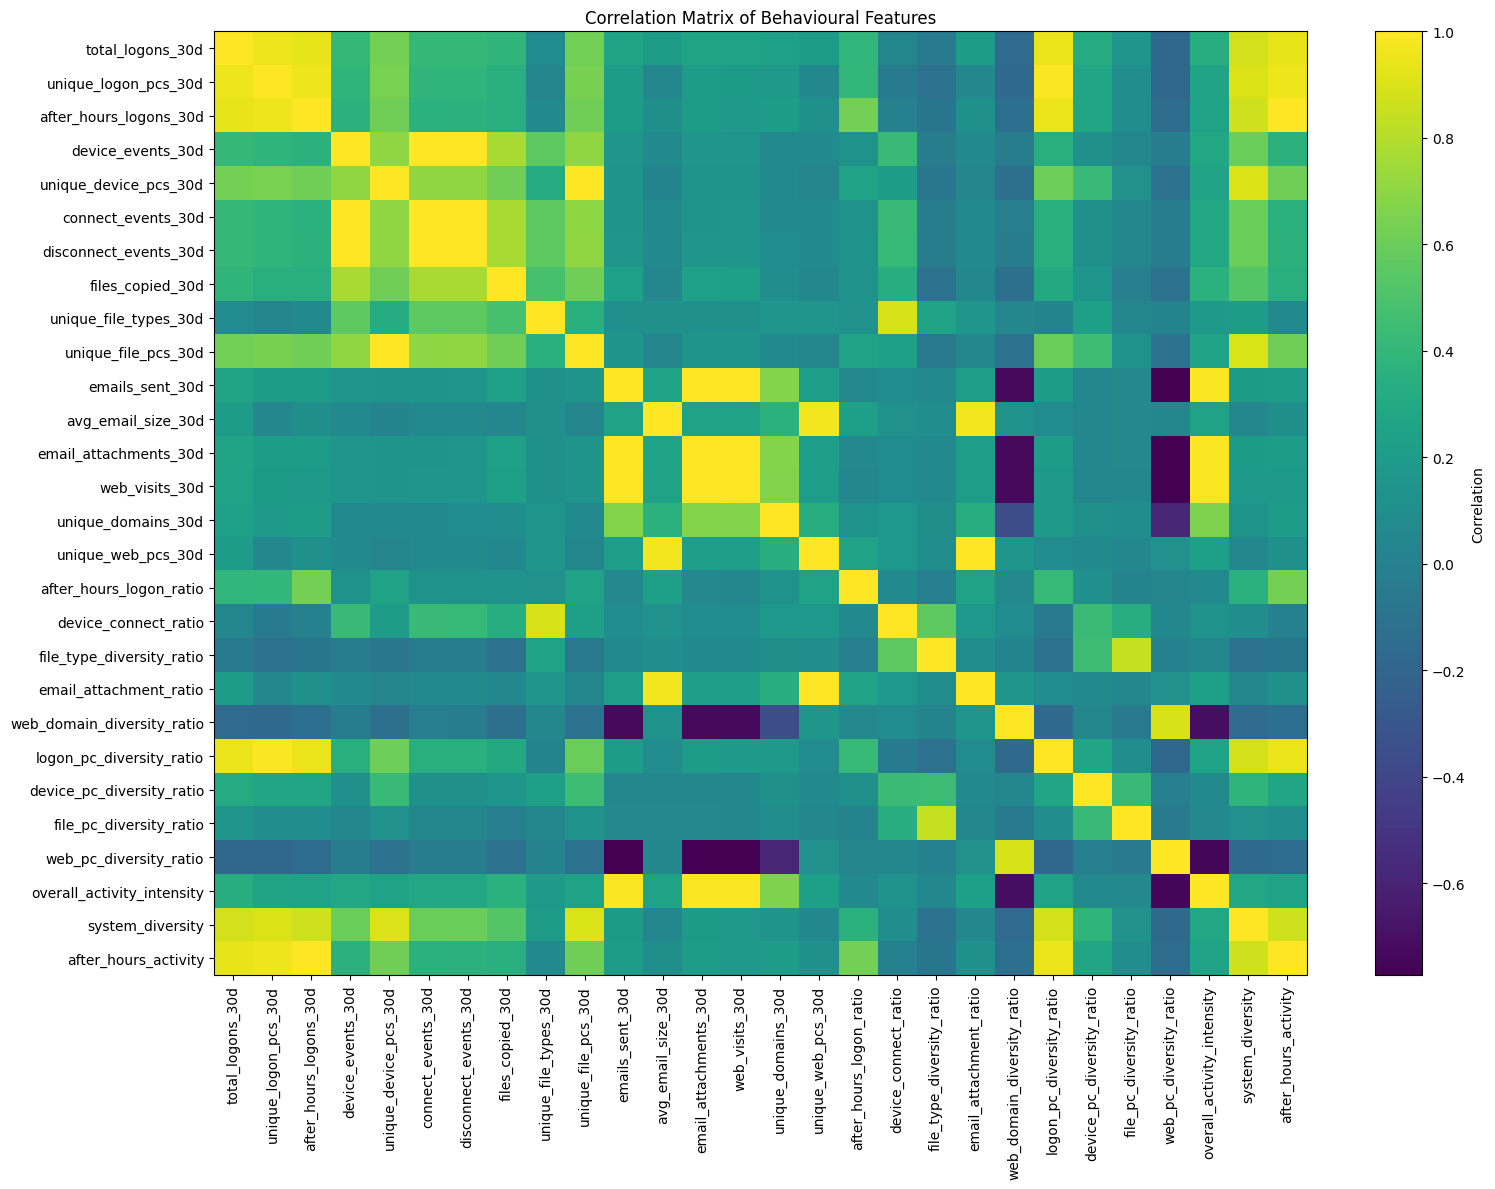

In [69]:
# Visualise correlations among predictive features

plt.figure(
    figsize=(16, 12)
)

plt.imshow(
    X_extended.corr(),
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(feature_columns_extended)),
    feature_columns_extended,
    rotation=90
)

plt.yticks(
    range(len(feature_columns_extended)),
    feature_columns_extended
)

plt.title(
    "Correlation Matrix of Behavioural Features"
)

plt.tight_layout()
plt.show()

### Compare feature distributions by insider-risk class

In [70]:
# Compare mean feature values between insider-risk and non-insider groups

group_means = (
    model_df
    .groupby("insider_label")[
        feature_columns_extended
    ]
    .mean()
    .T
)

group_means.columns = [
    "Non-insider",
    "Insider-risk"
]

group_means["Difference"] = (
    group_means["Insider-risk"] -
    group_means["Non-insider"]
)

display(
    group_means.sort_values(
        "Difference",
        ascending=False
    )
)

,Non-insider,Insider-risk,Difference
avg_email_size_30d,28977.711119,29757.668011,779.956892
overall_activity_intensity,1957.157143,2124.242857,167.085714
web_visits_30d,1706.442857,1778.300000,71.857143
device_events_30d,19.628571,62.485714,42.857143
total_logons_30d,47.900000,72.485714,24.585714
after_hours_activity,16.928571,38.557143,21.628571
after_hours_logons_30d,16.928571,38.557143,21.628571
connect_events_30d,9.842857,31.357143,21.514286
disconnect_events_30d,9.785714,31.128571,21.342857
files_copied_30d,26.642857,46.757143,20.114286


### Finalise the modelling feature list

In [71]:
# Finalise the extended modelling feature set

feature_columns_final = feature_columns_extended.copy()

X = model_df[
    feature_columns_final
].copy()

y = model_df[
    "insider_label"
].copy()

print(
    "Final feature count:",
    len(feature_columns_final)
)

print(
    "Final feature matrix:",
    X.shape
)

print(
    "Target distribution:"
)

print(
    y.value_counts()
)

Final feature count: 28
Final feature matrix: (140, 28)
Target distribution:
insider_label
1    70
0    70
Name: count, dtype: int64


### Create the final train/test split

In [72]:
# Create a stratified train-test split

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training observations: 112
Testing observations: 28

Training class distribution:
insider_label
0    56
1    56
Name: count, dtype: int64

Testing class distribution:
insider_label
1    14
0    14
Name: count, dtype: int64


### Verify employee separation

In [73]:
# Verify that no employee appears in both training and testing

train_users = set(
    model_df.loc[X_train.index, "user"]
)

test_users = set(
    model_df.loc[X_test.index, "user"]
)

user_overlap = train_users.intersection(
    test_users
)

print("Training users:", len(train_users))
print("Testing users:", len(test_users))
print("Employee overlap:", len(user_overlap))

if user_overlap:
    print("\nOverlapping users:")
    print(user_overlap)
else:
    print("\nNo employee overlap detected.")

Training users: 112
Testing users: 28
Employee overlap: 0

No employee overlap detected.


### Define the four candidate models

In [75]:
# Import the required machine-learning classifiers

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

print("All model imports loaded successfully.")


All model imports loaded successfully.


In [76]:
# Define the candidate machine-learning models

logistic_model = Pipeline([
    (
        "scaler",
        RobustScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

svm_model = Pipeline([
    (
        "scaler",
        RobustScaler()
    ),
    (
        "classifier",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        )
    )
])

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

gradient_boosting = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgboost_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

models = {
    "Logistic Regression": logistic_model,
    "SVM": svm_model,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
    "XGBoost": xgboost_model
}

print("Models defined successfully:")

for name in models:
    print("-", name)

Models defined successfully:
- Logistic Regression
- SVM
- Random Forest
- Gradient Boosting
- XGBoost


### Train the five candidate models

In [77]:
# Train all candidate models on the training data

for name, model in models.items():
    
    model.fit(
        X_train,
        y_train
    )
    
    print(
        f"{name}: training completed"
    )

Logistic Regression: training completed
SVM: training completed
Random Forest: training completed
Gradient Boosting: training completed
XGBoost: training completed


### Evaluate the five models

In [78]:
# Evaluate all candidate models on the unseen test set

results = []

for name, model in models.items():
    
    y_pred = model.predict(
        X_test
    )
    
    y_prob = model.predict_proba(
        X_test
    )[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "Average Precision": average_precision_score(
            y_test,
            y_prob
        )
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901
1,XGBoost,0.9286,0.8750,1.0000,0.9333,0.9490,0.9338
2,Logistic Regression,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660
3,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9235,0.8806
4,SVM,0.6429,0.7500,0.4286,0.5455,0.8878,0.8799


### Detailed classification reports

In [79]:
# Generate class-level performance reports

for name, model in models.items():
    
    y_pred = model.predict(
        X_test
    )
    
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Non-insider",
                "Insider-risk"
            ],
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

 Non-insider     0.9231    0.8571    0.8889        14
Insider-risk     0.8667    0.9286    0.8966        14

    accuracy                         0.8929        28
   macro avg     0.8949    0.8929    0.8927        28
weighted avg     0.8949    0.8929    0.8927        28


SVM
              precision    recall  f1-score   support

 Non-insider     0.6000    0.8571    0.7059        14
Insider-risk     0.7500    0.4286    0.5455        14

    accuracy                         0.6429        28
   macro avg     0.6750    0.6429    0.6257        28
weighted avg     0.6750    0.6429    0.6257        28


Random Forest
              precision    recall  f1-score   support

 Non-insider     1.0000    0.8571    0.9231        14
Insider-risk     0.8750    1.0000    0.9333        14

    accuracy                         0.9286        28
   macro avg     0.9375    0.9286    0.9282        28
weighted avg     0.9375    0.9286

### Confusion matrices

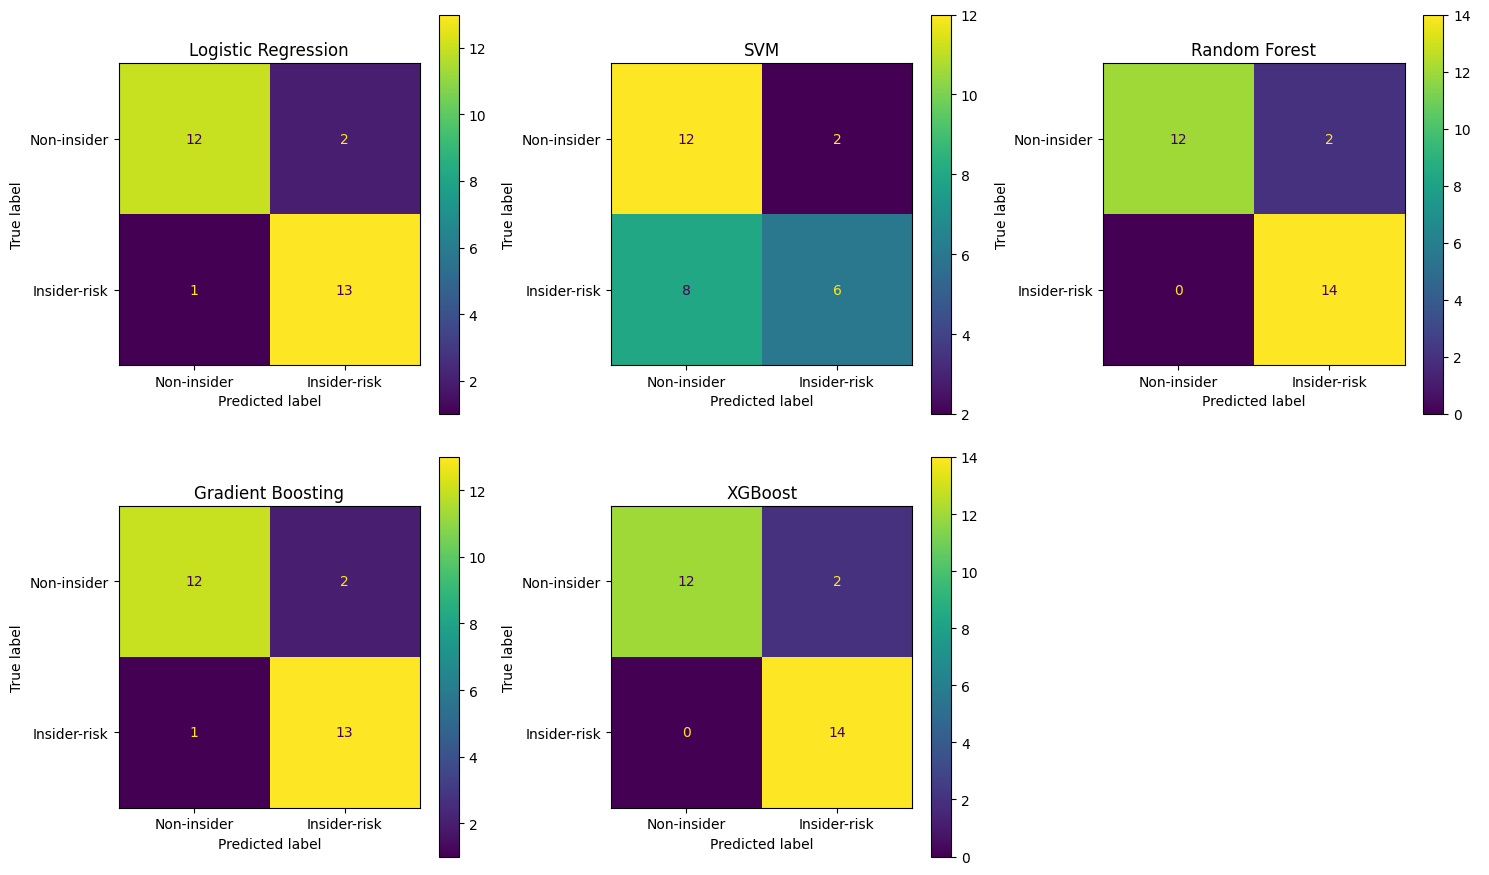

In [80]:
# Generate confusion matrices for all five models

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.ravel()

for ax, (name, model) in zip(
    axes,
    models.items()
):
    
    y_pred = model.predict(
        X_test
    )
    
    cm = confusion_matrix(
        y_test,
        y_pred
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Non-insider",
            "Insider-risk"
        ]
    )
    
    disp.plot(
        ax=ax,
        values_format="d"
    )
    
    ax.set_title(name)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### ROC curves

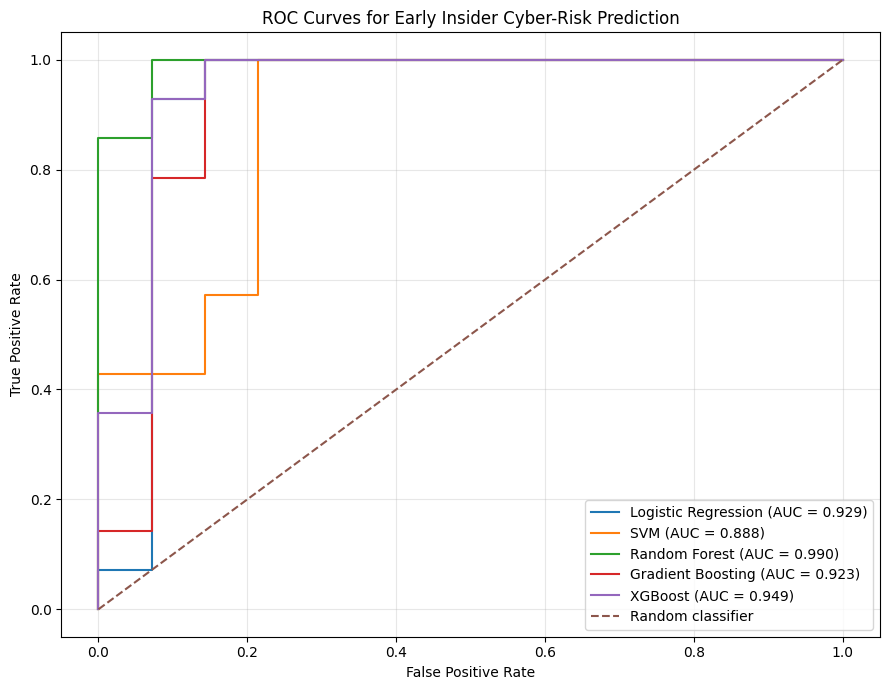

In [81]:
# Compare ROC curves across the five candidate models

plt.figure(
    figsize=(9, 7)
)

for name, model in models.items():
    
    y_prob = model.predict_proba(
        X_test
    )[:, 1]
    
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )
    
    auc = roc_auc_score(
        y_test,
        y_prob
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves for Early Insider Cyber-Risk Prediction"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Precision-recall curves
This is particularly valuable because an insider-threat system must balance detecting risk against generating unnecessary alerts.

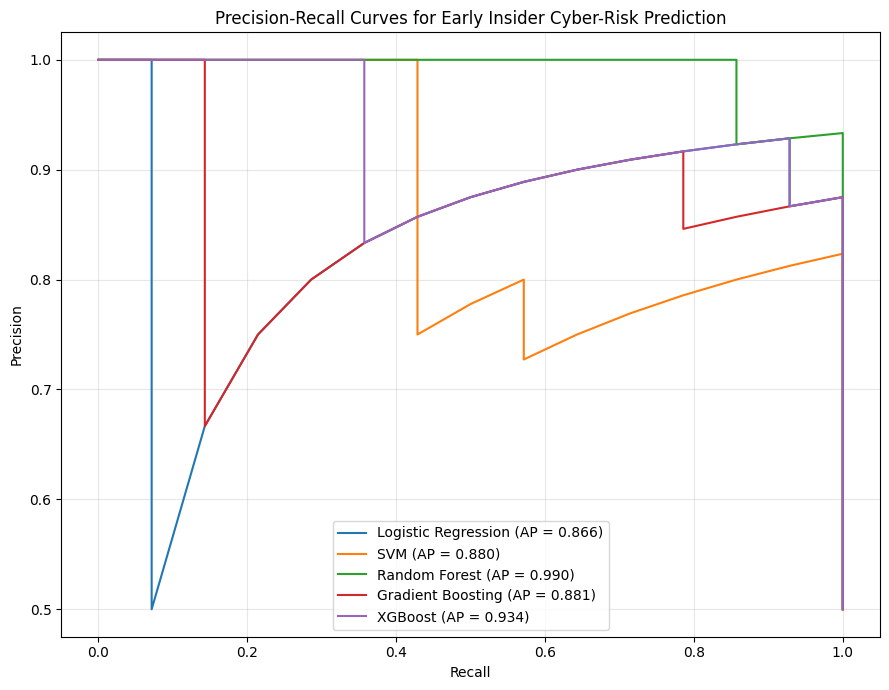

In [82]:
# Compare precision-recall curves across the five models

plt.figure(
    figsize=(9, 7)
)

for name, model in models.items():
    
    y_prob = model.predict_proba(
        X_test
    )[:, 1]
    
    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )
    
    ap = average_precision_score(
        y_test,
        y_prob
    )
    
    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap:.3f})"
    )

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curves for Early Insider Cyber-Risk Prediction"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
# Save the candidate model comparison results

results_df.to_csv(
    "early_insider_model_comparison.csv",
    index=False
)

print(
    "Model comparison saved successfully."
)

Model comparison saved successfully.


### Set up stratified cross-validation

In [84]:
# Set up stratified cross-validation

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print("Folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Cross-validation strategy:
Folds: 5
Shuffle: True
Random state: 42


### Cross-validate the five baseline models

We'll evaluate ROC-AUC, precision, recall and F1 across the five folds.

In [85]:
# Evaluate baseline models using stratified cross-validation

cv_results = []

for name, model in models.items():
    
    fold_auc = []
    fold_precision = []
    fold_recall = []
    fold_f1 = []
    
    for train_idx, valid_idx in cv.split(
        X,
        y
    ):
        
        X_cv_train = X.iloc[train_idx]
        X_cv_valid = X.iloc[valid_idx]
        
        y_cv_train = y.iloc[train_idx]
        y_cv_valid = y.iloc[valid_idx]
        
        model_clone = clone(model)
        
        model_clone.fit(
            X_cv_train,
            y_cv_train
        )
        
        y_cv_pred = model_clone.predict(
            X_cv_valid
        )
        
        y_cv_prob = model_clone.predict_proba(
            X_cv_valid
        )[:, 1]
        
        fold_auc.append(
            roc_auc_score(
                y_cv_valid,
                y_cv_prob
            )
        )
        
        fold_precision.append(
            precision_score(
                y_cv_valid,
                y_cv_pred,
                zero_division=0
            )
        )
        
        fold_recall.append(
            recall_score(
                y_cv_valid,
                y_cv_pred,
                zero_division=0
            )
        )
        
        fold_f1.append(
            f1_score(
                y_cv_valid,
                y_cv_pred,
                zero_division=0
            )
        )
    
    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": np.mean(fold_auc),
        "Std ROC-AUC": np.std(fold_auc),
        "Mean Precision": np.mean(fold_precision),
        "Mean Recall": np.mean(fold_recall),
        "Mean F1": np.mean(fold_f1)
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        "Mean ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    cv_results_df.round(4)
)

,Model,Mean ROC-AUC,Std ROC-AUC,Mean Precision,Mean Recall,Mean F1
0,Logistic Regression,0.9643,0.0202,0.8640,0.9714,0.9124
1,XGBoost,0.9602,0.0217,0.8611,0.9429,0.8965
2,Gradient Boosting,0.9541,0.0180,0.8639,0.9429,0.8984
3,Random Forest,0.9454,0.0358,0.8417,0.9714,0.9004
4,SVM,0.9194,0.0520,0.6992,0.2714,0.3701


### Compare test performance with cross-validation

In [86]:
# Compare held-out test performance with cross-validation performance

test_summary = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ]
].copy()

cv_summary = cv_results_df[
    [
        "Model",
        "Mean ROC-AUC",
        "Std ROC-AUC",
        "Mean Precision",
        "Mean Recall",
        "Mean F1"
    ]
].copy()

combined_results = test_summary.merge(
    cv_summary,
    on="Model"
)

display(
    combined_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Mean ROC-AUC,Std ROC-AUC,Mean Precision,Mean Recall,Mean F1
0,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901,0.9454,0.0358,0.8417,0.9714,0.9004
1,XGBoost,0.9286,0.8750,1.0000,0.9333,0.9490,0.9338,0.9602,0.0217,0.8611,0.9429,0.8965
2,Logistic Regression,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660,0.9643,0.0202,0.8640,0.9714,0.9124
3,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9235,0.8806,0.9541,0.0180,0.8639,0.9429,0.8984
4,SVM,0.6429,0.7500,0.4286,0.5455,0.8878,0.8799,0.9194,0.0520,0.6992,0.2714,0.3701


### Identify the strongest candidates

In [87]:
# Rank models using the main early-detection criteria

ranking = combined_results.copy()

ranking["Composite_Score"] = (
    0.40 * ranking["Mean ROC-AUC"] +
    0.30 * ranking["Mean Recall"] +
    0.20 * ranking["Mean F1"] +
    0.10 * ranking["Mean Precision"]
)

ranking = ranking.sort_values(
    "Composite_Score",
    ascending=False
).reset_index(drop=True)

display(
    ranking[
        [
            "Model",
            "Mean ROC-AUC",
            "Mean Recall",
            "Mean F1",
            "Mean Precision",
            "Composite_Score"
        ]
    ].round(4)
)

,Model,Mean ROC-AUC,Mean Recall,Mean F1,Mean Precision,Composite_Score
0,Logistic Regression,0.9643,0.9714,0.9124,0.8640,0.9460
1,Random Forest,0.9454,0.9714,0.9004,0.8417,0.9338
2,XGBoost,0.9602,0.9429,0.8965,0.8611,0.9323
3,Gradient Boosting,0.9541,0.9429,0.8984,0.8639,0.9306
4,SVM,0.9194,0.2714,0.3701,0.6992,0.5931


### Tune all five models

In [88]:
# Import tools for systematic hyperparameter tuning

from sklearn.model_selection import GridSearchCV

print("GridSearchCV loaded successfully.")

GridSearchCV loaded successfully.


In [89]:
# Define controlled hyperparameter search spaces

param_grids = {

    "Logistic Regression": {
        "classifier__C": [
            0.01,
            0.1,
            1,
            10,
            100
        ],
        "classifier__solver": [
            "liblinear",
            "lbfgs"
        ]
    },

    "SVM": {
        "classifier__C": [
            0.1,
            1,
            10,
            100
        ],
        "classifier__gamma": [
            "scale",
            0.01,
            0.1,
            1
        ],
        "classifier__kernel": [
            "rbf"
        ]
    },

    "Random Forest": {
        "n_estimators": [
            200,
            400
        ],
        "max_depth": [
            None,
            5,
            10,
            20
        ],
        "min_samples_split": [
            2,
            5,
            10
        ],
        "min_samples_leaf": [
            1,
            2,
            4
        ],
        "max_features": [
            "sqrt",
            "log2"
        ]
    },

    "Gradient Boosting": {
        "n_estimators": [
            100,
            200
        ],
        "learning_rate": [
            0.03,
            0.05,
            0.1
        ],
        "max_depth": [
            2,
            3,
            4
        ],
        "min_samples_split": [
            2,
            5,
            10
        ],
        "min_samples_leaf": [
            1,
            2,
            4
        ]
    },

    "XGBoost": {
        "n_estimators": [
            100,
            200
        ],
        "learning_rate": [
            0.03,
            0.05,
            0.1
        ],
        "max_depth": [
            2,
            3,
            4
        ],
        "min_child_weight": [
            1,
            3,
            5
        ],
        "subsample": [
            0.8,
            1.0
        ],
        "colsample_bytree": [
            0.8,
            1.0
        ]
    }
}

print("Hyperparameter search spaces defined.")

Hyperparameter search spaces defined.


### Tune all five models

In [90]:
# Tune all five candidate models using stratified cross-validation

tuned_models = {}
tuning_results = []

for name, model in models.items():
    
    print("\n" + "=" * 60)
    print("Tuning:", name)
    print("=" * 60)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid_search.fit(
        X_train,
        y_train
    )

    tuned_models[name] = grid_search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best ROC-AUC CV": grid_search.best_score_,
        "Best Parameters": grid_search.best_params_
    })

    print(
        "Best ROC-AUC:",
        round(
            grid_search.best_score_,
            4
        )
    )

    print(
        "Best parameters:"
    )

    print(
        grid_search.best_params_
    )


Tuning: Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best ROC-AUC: 0.9539
Best parameters:
{'classifier__C': 0.1, 'classifier__solver': 'liblinear'}

Tuning: SVM
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best ROC-AUC: 0.9423
Best parameters:
{'classifier__C': 100, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

Tuning: Random Forest
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best ROC-AUC: 0.9167
Best parameters:
{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Tuning: Gradient Boosting
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best ROC-AUC: 0.9532
Best parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Tuning: XGBoost
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best ROC-AUC: 0.939
Best parameters:
{'colsample_bytree': 1.0, 'lea

### Display tuning results

In [91]:
# Display the best configuration identified for each model

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values(
        "Best ROC-AUC CV",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuning_results_df
)

,Model,Best ROC-AUC CV,Best Parameters
0,Logistic Regression,0.953857,"{'classifier__C': 0.1, 'classifier__solver': '..."
1,Gradient Boosting,0.953168,"{'learning_rate': 0.05, 'max_depth': 2, 'min_s..."
2,SVM,0.942287,"{'classifier__C': 100, 'classifier__gamma': 's..."
3,XGBoost,0.938981,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
4,Random Forest,0.916736,"{'max_depth': None, 'max_features': 'log2', 'm..."


### Evaluate the tuned models on the held-out test set

In [92]:
# Evaluate tuned models on the untouched test set

tuned_test_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    tuned_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "Average Precision": average_precision_score(
            y_test,
            y_prob
        )
    })

tuned_test_results_df = (
    pd.DataFrame(
        tuned_test_results
    )
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuned_test_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901
1,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9388,0.9182
2,SVM,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660
3,XGBoost,0.9286,0.9286,0.9286,0.9286,0.9235,0.8302
4,Logistic Regression,0.8929,0.8235,1.0000,0.9032,0.8878,0.8266


### Compare baseline and tuned performance

In [93]:
# Compare baseline and tuned model performance

baseline_comparison = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ]
].copy()

baseline_comparison["Version"] = "Baseline"

tuned_comparison = tuned_test_results_df.copy()

tuned_comparison["Version"] = "Tuned"

model_comparison = pd.concat(
    [
        baseline_comparison,
        tuned_comparison
    ],
    ignore_index=True
)

model_comparison = (
    model_comparison
    .sort_values(
        [
            "Model",
            "Version"
        ]
    )
    .reset_index(drop=True)
)

display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Version
0,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9235,0.8806,Baseline
1,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9388,0.9182,Tuned
2,Logistic Regression,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660,Baseline
3,Logistic Regression,0.8929,0.8235,1.0000,0.9032,0.8878,0.8266,Tuned
4,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901,Baseline
5,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901,Tuned
6,SVM,0.6429,0.7500,0.4286,0.5455,0.8878,0.8799,Baseline
7,SVM,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660,Tuned
8,XGBoost,0.9286,0.8750,1.0000,0.9333,0.9490,0.9338,Baseline
9,XGBoost,0.9286,0.9286,0.9286,0.9286,0.9235,0.8302,Tuned


### Save tuned models

In [94]:
# Save the tuned models for reproducibility

for name, model in tuned_models.items():

    filename = (
        name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )
        + "_tuned.joblib"
    )

    joblib.dump(
        model,
        filename
    )

    print(
        "Saved:",
        filename
    )

Saved: logistic_regression_tuned.joblib
Saved: svm_tuned.joblib
Saved: random_forest_tuned.joblib
Saved: gradient_boosting_tuned.joblib
Saved: xgboost_tuned.joblib


### Import SMOTE and imbalanced-learn pipeline

In [95]:
# Import SMOTE and the imbalanced-learning pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("SMOTE tools loaded successfully.")

SMOTE tools loaded successfully.


In [96]:
# Define SMOTE-enhanced versions of the candidate models

smote_models = {

    "Logistic Regression": ImbPipeline([
        (
            "scaler",
            RobustScaler()
        ),
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=5
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]),

    "SVM": ImbPipeline([
        (
            "scaler",
            RobustScaler()
        ),
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=5
            )
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                random_state=42
            )
        )
    ]),

    "Random Forest": ImbPipeline([
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=5
            )
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Gradient Boosting": ImbPipeline([
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=5
            )
        ),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]),

    "XGBoost": ImbPipeline([
        (
            "smote",
            SMOTE(
                random_state=42,
                k_neighbors=5
            )
        ),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

print("SMOTE models defined:")
for name in smote_models:
    print("-", name)

SMOTE models defined:
- Logistic Regression
- SVM
- Random Forest
- Gradient Boosting
- XGBoost


### Evaluate SMOTE using cross-validation

In [97]:
# Evaluate SMOTE models using stratified cross-validation

smote_cv_results = []

for name, model in smote_models.items():

    fold_auc = []
    fold_precision = []
    fold_recall = []
    fold_f1 = []

    for train_idx, valid_idx in cv.split(
        X,
        y
    ):

        X_cv_train = X.iloc[train_idx]
        X_cv_valid = X.iloc[valid_idx]

        y_cv_train = y.iloc[train_idx]
        y_cv_valid = y.iloc[valid_idx]

        model_clone = clone(model)

        model_clone.fit(
            X_cv_train,
            y_cv_train
        )

        y_cv_pred = model_clone.predict(
            X_cv_valid
        )

        y_cv_prob = model_clone.predict_proba(
            X_cv_valid
        )[:, 1]

        fold_auc.append(
            roc_auc_score(
                y_cv_valid,
                y_cv_prob
            )
        )

        fold_precision.append(
            precision_score(
                y_cv_valid,
                y_cv_pred,
                zero_division=0
            )
        )

        fold_recall.append(
            recall_score(
                y_cv_valid,
                y_cv_pred,
                zero_division=0
            )
        )

        fold_f1.append(
            f1_score(
                y_cv_valid,
                y_cv_pred,
                zero_division=0
            )
        )

    smote_cv_results.append({
        "Model": name,
        "SMOTE Mean ROC-AUC": np.mean(fold_auc),
        "SMOTE Std ROC-AUC": np.std(fold_auc),
        "SMOTE Mean Precision": np.mean(fold_precision),
        "SMOTE Mean Recall": np.mean(fold_recall),
        "SMOTE Mean F1": np.mean(fold_f1)
    })

smote_cv_results_df = (
    pd.DataFrame(smote_cv_results)
    .sort_values(
        "SMOTE Mean ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    smote_cv_results_df.round(4)
)

,Model,SMOTE Mean ROC-AUC,SMOTE Std ROC-AUC,SMOTE Mean Precision,SMOTE Mean Recall,SMOTE Mean F1
0,Logistic Regression,0.9643,0.0202,0.8640,0.9714,0.9124
1,XGBoost,0.9602,0.0217,0.8611,0.9429,0.8965
2,Gradient Boosting,0.9541,0.0180,0.8639,0.9429,0.8984
3,Random Forest,0.9454,0.0358,0.8417,0.9714,0.9004
4,SVM,0.9194,0.0520,0.6992,0.2714,0.3701


### Train SMOTE models on the training set

In [98]:
# Train SMOTE models using only the training partition

smote_fitted_models = {}

for name, model in smote_models.items():

    model.fit(
        X_train,
        y_train
    )

    smote_fitted_models[name] = model

    print(
        f"{name}: SMOTE training completed"
    )

Logistic Regression: SMOTE training completed
SVM: SMOTE training completed
Random Forest: SMOTE training completed
Gradient Boosting: SMOTE training completed
XGBoost: SMOTE training completed


### Evaluate SMOTE models on the untouched test set

In [99]:
# Evaluate SMOTE models on the untouched test set

smote_test_results = []

for name, model in smote_fitted_models.items():

    y_pred = model.predict(
        X_test
    )

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    smote_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "Average Precision": average_precision_score(
            y_test,
            y_prob
        )
    })

smote_test_results_df = (
    pd.DataFrame(
        smote_test_results
    )
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    smote_test_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901
1,XGBoost,0.9286,0.8750,1.0000,0.9333,0.9490,0.9338
2,Logistic Regression,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660
3,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9235,0.8806
4,SVM,0.6429,0.7500,0.4286,0.5455,0.8878,0.8799


### Compare baseline, tuned and SMOTE models

In [100]:
# Combine baseline, tuned and SMOTE test results

baseline_results = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ]
].copy()

baseline_results["Experiment"] = "Baseline"

tuned_results = tuned_test_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ]
].copy()

tuned_results["Experiment"] = "Tuned"

smote_results = smote_test_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "Average Precision"
    ]
].copy()

smote_results["Experiment"] = "SMOTE"

all_experiment_results = pd.concat(
    [
        baseline_results,
        tuned_results,
        smote_results
    ],
    ignore_index=True
)

all_experiment_results = (
    all_experiment_results
    .sort_values(
        [
            "ROC-AUC",
            "F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    all_experiment_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Experiment
0,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901,Baseline
1,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901,Tuned
2,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901,SMOTE
3,XGBoost,0.9286,0.8750,1.0000,0.9333,0.9490,0.9338,Baseline
4,XGBoost,0.9286,0.8750,1.0000,0.9333,0.9490,0.9338,SMOTE
5,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9388,0.9182,Tuned
6,Logistic Regression,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660,Baseline
7,SVM,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660,Tuned
8,Logistic Regression,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660,SMOTE
9,XGBoost,0.9286,0.9286,0.9286,0.9286,0.9235,0.8302,Tuned


### Determine whether SMOTE actually helped

In [101]:
# Calculate the change produced by SMOTE for each model

smote_effect = baseline_results.merge(
    smote_results,
    on="Model",
    suffixes=(
        "_Baseline",
        "_SMOTE"
    )
)

smote_effect["ROC_AUC_Change"] = (
    smote_effect["ROC-AUC_SMOTE"] -
    smote_effect["ROC-AUC_Baseline"]
)

smote_effect["Recall_Change"] = (
    smote_effect["Recall_SMOTE"] -
    smote_effect["Recall_Baseline"]
)

smote_effect["F1_Change"] = (
    smote_effect["F1_SMOTE"] -
    smote_effect["F1_Baseline"]
)

display(
    smote_effect[
        [
            "Model",
            "ROC_AUC_Change",
            "Recall_Change",
            "F1_Change"
        ]
    ].round(4)
)

,Model,ROC_AUC_Change,Recall_Change,F1_Change
0,Random Forest,0.0,0.0,0.0
1,XGBoost,0.0,0.0,0.0
2,Logistic Regression,0.0,0.0,0.0
3,Gradient Boosting,0.0,0.0,0.0
4,SVM,0.0,0.0,0.0


### Inspect tuned model performance

In [102]:
# Rank the tuned models by predictive performance

tuned_ranking = (
    tuned_test_results_df
    .sort_values(
        [
            "ROC-AUC",
            "F1",
            "Recall"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tuned_ranking.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Random Forest,0.9286,0.8750,1.0000,0.9333,0.9898,0.9901
1,Gradient Boosting,0.8929,0.8667,0.9286,0.8966,0.9388,0.9182
2,SVM,0.8929,0.8667,0.9286,0.8966,0.9286,0.8660
3,XGBoost,0.9286,0.9286,0.9286,0.9286,0.9235,0.8302
4,Logistic Regression,0.8929,0.8235,1.0000,0.9032,0.8878,0.8266


### Identify the strongest tuned models

In [103]:
# Identify the strongest tuned models for ensemble construction

ensemble_candidates = (
    tuned_ranking
    .head(3)
    ["Model"]
    .tolist()
)

print(
    "Selected ensemble candidates:"
)

for model_name in ensemble_candidates:
    print(
        "-",
        model_name
    )

Selected ensemble candidates:
- Random Forest
- Gradient Boosting
- SVM


### Build the soft Voting Ensemble

In [104]:
# Import the soft voting ensemble classifier

from sklearn.ensemble import VotingClassifier

print("VotingClassifier loaded successfully.")

VotingClassifier loaded successfully.


In [106]:
# Build the soft voting ensemble from the three strongest tuned models

voting_ensemble = VotingClassifier(
    estimators=[
        (
            "random_forest",
            tuned_models["Random Forest"]
        ),
        (
            "gradient_boosting",
            tuned_models["Gradient Boosting"]
        ),
        (
            "svm",
            tuned_models["SVM"]
        )
    ],
    voting="soft"
)

print(
    "Voting Ensemble configured:"
)

print(
    "Random Forest + Gradient Boosting + SVM"
)

Voting Ensemble configured:
Random Forest + Gradient Boosting + SVM


### Train the ensemble

In [107]:
# Train the soft voting ensemble on the training data

voting_ensemble.fit(
    X_train,
    y_train
)

print(
    "Voting Ensemble training completed."
)

Voting Ensemble training completed.


### Evaluate the ensemble

In [108]:
# Evaluate the Voting Ensemble on the untouched test set

ensemble_pred = voting_ensemble.predict(
    X_test
)

ensemble_prob = voting_ensemble.predict_proba(
    X_test
)[:, 1]

ensemble_results = pd.DataFrame([{
    "Model": "Voting Ensemble",
    "Accuracy": accuracy_score(
        y_test,
        ensemble_pred
    ),
    "Precision": precision_score(
        y_test,
        ensemble_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        ensemble_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        ensemble_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        ensemble_prob
    ),
    "Average Precision": average_precision_score(
        y_test,
        ensemble_prob
    )
}])

display(
    ensemble_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Voting Ensemble,0.9286,0.875,1.0,0.9333,0.9541,0.944


### Compare ensemble against the tuned models

# Compare the Voting Ensemble with the tuned candidate models

final_model_comparison = pd.concat(
    [
        tuned_test_results_df,
        ensemble_results
    ],
    ignore_index=True
)

final_model_comparison = (
    final_model_comparison
    .sort_values(
        [
            "ROC-AUC",
            "F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_model_comparison.round(4)
)

### Generate the ensemble classification report

In [110]:
# Generate the detailed classification report for the ensemble

print(
    classification_report(
        y_test,
        ensemble_pred,
        target_names=[
            "Non-insider",
            "Insider-risk"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-insider     1.0000    0.8571    0.9231        14
Insider-risk     0.8750    1.0000    0.9333        14

    accuracy                         0.9286        28
   macro avg     0.9375    0.9286    0.9282        28
weighted avg     0.9375    0.9286    0.9282        28



### Generate the ensemble confusion matrix

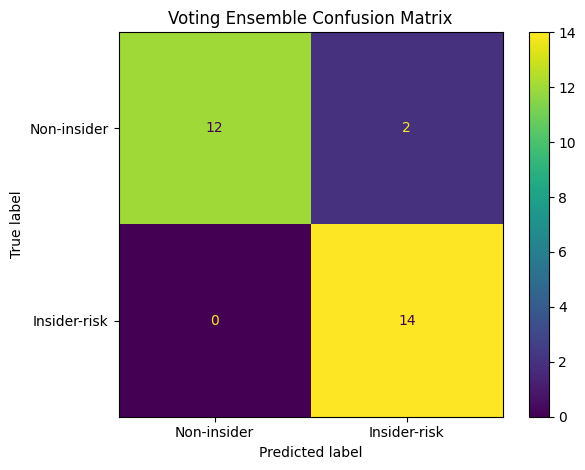

In [111]:
# Display the Voting Ensemble confusion matrix

ensemble_cm = confusion_matrix(
    y_test,
    ensemble_pred
)

ensemble_display = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_cm,
    display_labels=[
        "Non-insider",
        "Insider-risk"
    ]
)

ensemble_display.plot(
    values_format="d"
)

plt.title(
    "Voting Ensemble Confusion Matrix"
)

plt.tight_layout()
plt.show()

### Plot the ensemble ROC curve

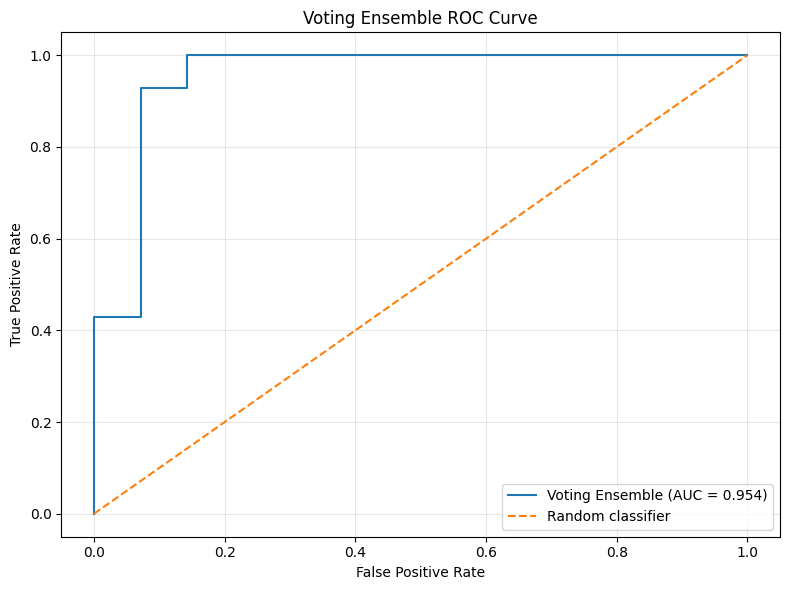

In [112]:
# Plot the ROC curve for the Voting Ensemble

ensemble_fpr, ensemble_tpr, _ = roc_curve(
    y_test,
    ensemble_prob
)

ensemble_auc = roc_auc_score(
    y_test,
    ensemble_prob
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    ensemble_fpr,
    ensemble_tpr,
    label=f"Voting Ensemble (AUC = {ensemble_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Voting Ensemble ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
# Save the trained Voting Ensemble

joblib.dump(
    voting_ensemble,
    "early_insider_voting_ensemble.joblib"
)

print(
    "Voting Ensemble saved successfully."
)

Voting Ensemble saved successfully.


### Select the final model

In [114]:
# Select the final predictive model based on ROC-AUC, recall and F1

final_model_row = (
    final_model_comparison
    .sort_values(
        [
            "ROC-AUC",
            "Recall",
            "F1"
        ],
        ascending=False
    )
    .iloc[0]
)

final_model_name = final_model_row["Model"]

print("Selected final model:")
print(final_model_name)

print("\nFinal performance:")
display(
    final_model_row.to_frame().T.round(4)
)

Selected final model:
Random Forest

Final performance:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Random Forest,0.928571,0.875,1.0,0.933333,0.989796,0.990136


### Assign the selected model

In [115]:
# Assign the selected model object for final analysis

if final_model_name == "Voting Ensemble":
    final_model = voting_ensemble
else:
    final_model = tuned_models[final_model_name]

print(
    "Final model object:",
    type(final_model).__name__
)

Final model object: RandomForestClassifier


### Create the final test predictions

In [116]:
# Generate final predictions and risk probabilities

final_pred = final_model.predict(
    X_test
)

final_prob = final_model.predict_proba(
    X_test
)[:, 1]

print("Final predictions generated.")
print(
    "Number of test observations:",
    len(X_test)
)

Final predictions generated.
Number of test observations: 28


### Final performance summary

In [117]:
# Calculate the final model performance metrics

final_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        final_pred
    ),
    "Precision": precision_score(
        y_test,
        final_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        final_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        final_prob
    ),
    "Average Precision": average_precision_score(
        y_test,
        final_prob
    )
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

display(
    final_metrics_df.round(4)
)

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,0.9286,0.875,1.0,0.9333,0.9898,0.9901


### Final confusion matrix

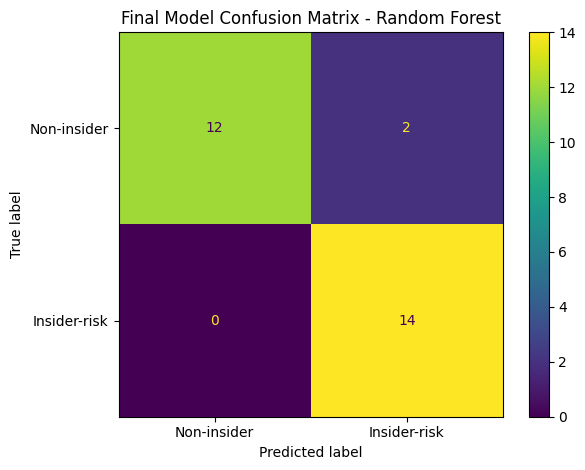

In [118]:
# Display the final model confusion matrix

final_cm = confusion_matrix(
    y_test,
    final_pred
)

final_display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "Non-insider",
        "Insider-risk"
    ]
)

final_display.plot(
    values_format="d"
)

plt.title(
    f"Final Model Confusion Matrix - {final_model_name}"
)

plt.tight_layout()
plt.show()

### Save the final model metrics

In [119]:
# Save the final model performance metrics

final_metrics_df.to_csv(
    "final_model_performance.csv",
    index=False
)

print(
    "Final model performance saved."
)

Final model performance saved.


### Prepare the SHAP evaluation data

In [120]:
# Prepare the held-out test data for SHAP analysis

X_shap = X_test.copy()

print(
    "SHAP feature matrix shape:",
    X_shap.shape
)

print(
    "Number of features:",
    X_shap.shape[1]
)

print(
    "Number of observations:",
    X_shap.shape[0]
)

SHAP feature matrix shape: (28, 28)
Number of features: 28
Number of observations: 28


In [121]:
# Determine the appropriate SHAP explanation strategy

if final_model_name == "Voting Ensemble":
    
    shap_strategy = "model_agnostic"
    
elif final_model_name in [
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]:
    
    shap_strategy = "tree"
    
else:
    
    shap_strategy = "model_agnostic"

print(
    "SHAP explanation strategy:",
    shap_strategy
)

SHAP explanation strategy: tree


### Create the SHAP explainer

In [124]:
# Import SHAP and create the appropriate explainer

try:
    import shap
except ImportError:
    print("SHAP is not installed.")
    print("Run: %pip install shap")
    raise

print("SHAP version:", shap.__version__)

print("Final model:", final_model_name)
print("Model class:", type(final_model).__name__)

if final_model_name in [
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]:

    shap_explainer = shap.TreeExplainer(
        final_model
    )

    shap_strategy = "TreeExplainer"

else:

    background_size = min(
        50,
        len(X_train)
    )

    background_data = shap.sample(
        X_train,
        background_size,
        random_state=42
    )

    shap_explainer = shap.Explainer(
        final_model.predict_proba,
        background_data
    )

    shap_strategy = "Model-agnostic SHAP"

print(
    "SHAP strategy:",
    shap_strategy
)

print(
    "SHAP explainer created successfully."
)

SHAP version: 0.51.0
Final model: Random Forest
Model class: RandomForestClassifier
SHAP strategy: TreeExplainer
SHAP explainer created successfully.


In [125]:
# Calculate SHAP values for all modelling observations

X_all_shap = X.copy()

shap_all_output = shap_explainer(
    X_all_shap
)

print(
    "Full-dataset SHAP calculated."
)

print(
    "SHAP output shape:",
    shap_all_output.values.shape
)

Full-dataset SHAP calculated.
SHAP output shape: (140, 28, 2)


In [126]:
# Extract SHAP values for the insider-risk class

shap_values_raw = shap_all_output.values

if shap_values_raw.ndim == 3:

    shap_all_values = shap_values_raw[:, :, 1]

else:

    shap_all_values = shap_values_raw

print(
    "SHAP values shape:",
    shap_all_values.shape
)

print(
    "Feature matrix shape:",
    X_all_shap.shape
)

SHAP values shape: (140, 28)
Feature matrix shape: (140, 28)


In [127]:
# Verify SHAP dimensions

assert shap_all_values.shape == X_all_shap.shape

print(
    "SHAP dimension check passed."
)

SHAP dimension check passed.


### Generate SHAP values for all 140 observations

First, make sure the SHAP values are available.

In [128]:
# Generate SHAP values for the complete modelling population

X_all_shap = X.copy()

shap_all_output = shap_explainer(
    X_all_shap
)

shap_values_raw = shap_all_output.values

if shap_values_raw.ndim == 3:

    shap_all_values = shap_values_raw[:, :, 1]

else:

    shap_all_values = shap_values_raw

assert (
    shap_all_values.shape ==
    X_all_shap.shape
)

print(
    "SHAP observations:",
    shap_all_values.shape[0]
)

print(
    "SHAP features:",
    shap_all_values.shape[1]
)

SHAP observations: 140
SHAP features: 28


### Create an analyst-readable SHAP table

In [130]:
# Create an analyst-readable SHAP contribution table

shap_contributions = pd.DataFrame(
    shap_all_values,
    columns=X_all_shap.columns,
    index=X_all_shap.index
)

print(
    "SHAP contribution table shape:",
    shap_contributions.shape
)

display(
    shap_contributions.head()
)

SHAP contribution table shape: (140, 28)


,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,files_copied_30d,unique_file_types_30d,unique_file_pcs_30d,...,file_type_diversity_ratio,email_attachment_ratio,web_domain_diversity_ratio,logon_pc_diversity_ratio,device_pc_diversity_ratio,file_pc_diversity_ratio,web_pc_diversity_ratio,overall_activity_intensity,system_diversity,after_hours_activity
0,0.011378,0.002946,0.006040,0.022586,0.018467,0.041998,0.041473,0.027799,0.006241,0.013564,...,0.037909,0.000005,0.007909,0.004505,0.049222,0.064101,-0.001672,0.001942,0.045435,0.008361
1,0.023685,0.004841,0.000012,0.016047,0.018710,0.036484,0.039125,0.031110,0.007425,0.012190,...,0.038711,0.000008,0.009151,0.014224,0.030004,0.068699,0.005555,0.004639,0.048782,0.003701
2,0.021097,0.003282,-0.001073,0.024465,0.015390,0.038026,0.040683,0.029898,0.007990,0.012200,...,0.043949,0.000008,-0.012045,0.010869,0.038927,0.078058,-0.004658,0.001825,0.046572,0.006761
3,-0.009614,0.007371,0.005356,0.015920,0.016562,0.034542,0.034387,0.024960,0.007179,0.011398,...,0.030625,0.000008,0.006238,-0.001401,0.024227,0.061504,-0.002843,0.003203,0.045198,0.005952
4,-0.010902,0.004028,0.004019,0.027382,0.018196,0.041903,0.045457,0.027854,0.013175,0.013326,...,0.038104,0.000008,0.008605,-0.000777,0.060132,0.061976,0.002607,-0.000083,0.045569,0.000223


### Generate model risk probabilities

In [131]:
# Generate insider-risk probabilities for all modelling observations

all_risk_probabilities = (
    final_model.predict_proba(
        X_all_shap
    )[:, 1]
)

print(
    "Risk probabilities generated."
)

print(
    "Minimum risk score:",
    round(
        all_risk_probabilities.min(),
        4
    )
)

print(
    "Maximum risk score:",
    round(
        all_risk_probabilities.max(),
        4
    )
)

Risk probabilities generated.
Minimum risk score: 0.0
Maximum risk score: 1.0


### Create the security-alert dataset

In [132]:
# Create a security analyst alert dataset

security_alerts = X_all_shap.copy()

security_alerts.insert(
    0,
    "user",
    model_df.loc[
        X_all_shap.index,
        "user"
    ].values
)

security_alerts["actual_label"] = (
    y.loc[
        X_all_shap.index
    ].values
)

security_alerts["risk_score"] = (
    all_risk_probabilities
)

print(
    "Security alert dataset created."
)

display(
    security_alerts.head()
)

Security alert dataset created.


,user,total_logons_30d,unique_logon_pcs_30d,after_hours_logons_30d,device_events_30d,unique_device_pcs_30d,connect_events_30d,disconnect_events_30d,files_copied_30d,unique_file_types_30d,...,web_domain_diversity_ratio,logon_pc_diversity_ratio,device_pc_diversity_ratio,file_pc_diversity_ratio,web_pc_diversity_ratio,overall_activity_intensity,system_diversity,after_hours_activity,actual_label,risk_score
0,AAM0658,46,1,24,6,1,3,3,11,3,...,0.121260,0.021739,0.166667,0.090909,0.001575,764,4,24,1,0.970
1,AJR0932,44,1,23,16,1,8,8,24,4,...,0.067547,0.022727,0.062500,0.041667,0.000508,2238,4,23,1,0.980
2,BDV0168,44,1,23,10,1,5,5,15,4,...,0.036472,0.022727,0.100000,0.066667,0.000299,3724,4,23,1,0.950
3,BIH0745,48,1,15,20,1,10,10,41,5,...,0.073525,0.020833,0.050000,0.024390,0.000296,3793,4,15,1,0.840
4,BLS0678,59,1,8,4,1,2,2,5,2,...,0.073274,0.016949,0.250000,0.200000,0.000527,2142,4,8,1,0.945


### Assign risk categories

In [133]:
# Assign risk categories for analyst prioritisation

def assign_risk_category(
    score
):

    if score >= 0.80:
        return "High"

    elif score >= 0.50:
        return "Medium"

    else:
        return "Low"


security_alerts["risk_category"] = (
    security_alerts[
        "risk_score"
    ].apply(
        assign_risk_category
    )
)

print(
    "Risk categories assigned."
)

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "actual_label"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

Risk categories assigned.


,user,risk_score,risk_category,actual_label
38,EDB0714,1.000,High,1
12,GHL0460,1.000,High,1
48,LCC0819,0.995,High,1
20,MAR0955,0.990,High,1
56,RMW0542,0.990,High,1
34,CEJ0109,0.990,High,1
50,MOS0047,0.985,High,1
49,MDH0580,0.985,High,1
45,IUB0565,0.985,High,1
35,CQW0652,0.985,High,1


### Identify the strongest evidence for each alert

In [134]:
# Identify the strongest risk-increasing features for every observation

def get_top_positive_features(
    row,
    n=5
):

    positive_features = (
        row[row > 0]
        .sort_values(
            ascending=False
        )
        .head(n)
    )

    return positive_features.index.tolist()


top_positive_features = []

for index in shap_contributions.index:

    top_features = get_top_positive_features(
        shap_contributions.loc[index],
        n=5
    )

    top_positive_features.append(
        ", ".join(top_features)
    )

security_alerts[
    "top_risk_drivers"
] = top_positive_features

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "top_risk_drivers"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

,user,risk_score,risk_category,top_risk_drivers
38,EDB0714,1.000,High,"file_pc_diversity_ratio, disconnect_events_30d..."
12,GHL0460,1.000,High,"file_pc_diversity_ratio, system_diversity, con..."
48,LCC0819,0.995,High,"file_pc_diversity_ratio, connect_events_30d, d..."
20,MAR0955,0.990,High,"file_pc_diversity_ratio, system_diversity, con..."
56,RMW0542,0.990,High,"file_pc_diversity_ratio, connect_events_30d, s..."
34,CEJ0109,0.990,High,"file_pc_diversity_ratio, system_diversity, con..."
50,MOS0047,0.985,High,"system_diversity, file_pc_diversity_ratio, dev..."
49,MDH0580,0.985,High,"file_pc_diversity_ratio, connect_events_30d, s..."
45,IUB0565,0.985,High,"file_pc_diversity_ratio, connect_events_30d, s..."
35,CQW0652,0.985,High,"file_pc_diversity_ratio, disconnect_events_30d..."


### Identify the strongest evidence against the alert

In [135]:
# Identify the strongest features reducing the insider-risk prediction

def get_top_negative_features(
    row,
    n=5
):

    negative_features = (
        row[row < 0]
        .abs()
        .sort_values(
            ascending=False
        )
        .head(n)
    )

    return negative_features.index.tolist()


top_negative_features = []

for index in shap_contributions.index:

    top_features = get_top_negative_features(
        shap_contributions.loc[index],
        n=5
    )

    top_negative_features.append(
        ", ".join(top_features)
    )

security_alerts[
    "evidence_against_risk"
] = top_negative_features

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "top_risk_drivers",
            "evidence_against_risk"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

,user,risk_score,risk_category,top_risk_drivers,evidence_against_risk
38,EDB0714,1.000,High,"file_pc_diversity_ratio, disconnect_events_30d...",
12,GHL0460,1.000,High,"file_pc_diversity_ratio, system_diversity, con...",
48,LCC0819,0.995,High,"file_pc_diversity_ratio, connect_events_30d, d...",unique_domains_30d
20,MAR0955,0.990,High,"file_pc_diversity_ratio, system_diversity, con...",avg_email_size_30d
56,RMW0542,0.990,High,"file_pc_diversity_ratio, connect_events_30d, s...",unique_domains_30d
34,CEJ0109,0.990,High,"file_pc_diversity_ratio, system_diversity, con...",
50,MOS0047,0.985,High,"system_diversity, file_pc_diversity_ratio, dev...","file_type_diversity_ratio, web_domain_diversit..."
49,MDH0580,0.985,High,"file_pc_diversity_ratio, connect_events_30d, s...",
45,IUB0565,0.985,High,"file_pc_diversity_ratio, connect_events_30d, s...","after_hours_logon_ratio, unique_domains_30d"
35,CQW0652,0.985,High,"file_pc_diversity_ratio, disconnect_events_30d...",after_hours_logons_30d


### Detect potentially questionable alerts

In [136]:
# Measure how concentrated each prediction's explanation is

absolute_shap = np.abs(
    shap_contributions
)

total_shap_magnitude = (
    absolute_shap.sum(
        axis=1
    )
)

top_five_shap_magnitude = (
    absolute_shap
    .apply(
        lambda row:
        row.nlargest(5).sum(),
        axis=1
    )
)

security_alerts[
    "top5_explanation_share"
] = (
    top_five_shap_magnitude /
    total_shap_magnitude.replace(
        0,
        np.nan
    )
)

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "top5_explanation_share"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

,user,risk_score,risk_category,top5_explanation_share
38,EDB0714,1.000,High,0.509771
12,GHL0460,1.000,High,0.488524
48,LCC0819,0.995,High,0.522726
20,MAR0955,0.990,High,0.477978
56,RMW0542,0.990,High,0.500154
34,CEJ0109,0.990,High,0.515631
50,MOS0047,0.985,High,0.459078
49,MDH0580,0.985,High,0.524106
45,IUB0565,0.985,High,0.505447
35,CQW0652,0.985,High,0.509593


### Detect possible false-positive candidates

In [137]:
# Identify high-risk observations requiring enhanced analyst review

security_alerts[
    "review_priority"
] = "Routine"

security_alerts.loc[
    security_alerts["risk_score"] >= 0.50,
    "review_priority"
] = "Review"

security_alerts.loc[
    (
        security_alerts["risk_score"] >= 0.80
    ) &
    (
        security_alerts["top5_explanation_share"] < 0.50
    ),
    "review_priority"
] = "Enhanced Review"
    
print(
    "Review priorities assigned."
)

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "review_priority",
            "top_risk_drivers",
            "evidence_against_risk"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

Review priorities assigned.


,user,risk_score,risk_category,review_priority,top_risk_drivers,evidence_against_risk
38,EDB0714,1.000,High,Review,"file_pc_diversity_ratio, disconnect_events_30d...",
12,GHL0460,1.000,High,Enhanced Review,"file_pc_diversity_ratio, system_diversity, con...",
48,LCC0819,0.995,High,Review,"file_pc_diversity_ratio, connect_events_30d, d...",unique_domains_30d
20,MAR0955,0.990,High,Enhanced Review,"file_pc_diversity_ratio, system_diversity, con...",avg_email_size_30d
56,RMW0542,0.990,High,Review,"file_pc_diversity_ratio, connect_events_30d, s...",unique_domains_30d
34,CEJ0109,0.990,High,Review,"file_pc_diversity_ratio, system_diversity, con...",
50,MOS0047,0.985,High,Enhanced Review,"system_diversity, file_pc_diversity_ratio, dev...","file_type_diversity_ratio, web_domain_diversit..."
49,MDH0580,0.985,High,Review,"file_pc_diversity_ratio, connect_events_30d, s...",
45,IUB0565,0.985,High,Review,"file_pc_diversity_ratio, connect_events_30d, s...","after_hours_logon_ratio, unique_domains_30d"
35,CQW0652,0.985,High,Review,"file_pc_diversity_ratio, disconnect_events_30d...",after_hours_logons_30d


In [139]:
# Identify high-risk observations requiring enhanced analyst review

security_alerts[
    "review_priority"
] = "Routine"

security_alerts.loc[
    security_alerts["risk_score"] >= 0.50,
    "review_priority"
] = "Review"

security_alerts.loc[
    (
        security_alerts["risk_score"] >= 0.80
    ) &
    (
        security_alerts["top5_explanation_share"] < 0.50
    ),
    "review_priority"
] = "Enhanced Review"
    
print(
    "Review priorities assigned."
)

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "review_priority",
            "top_risk_drivers",
            "evidence_against_risk"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
    .head(20)
)

Review priorities assigned.


,user,risk_score,risk_category,review_priority,top_risk_drivers,evidence_against_risk
38,EDB0714,1.000,High,Review,"file_pc_diversity_ratio, disconnect_events_30d...",
12,GHL0460,1.000,High,Enhanced Review,"file_pc_diversity_ratio, system_diversity, con...",
48,LCC0819,0.995,High,Review,"file_pc_diversity_ratio, connect_events_30d, d...",unique_domains_30d
20,MAR0955,0.990,High,Enhanced Review,"file_pc_diversity_ratio, system_diversity, con...",avg_email_size_30d
56,RMW0542,0.990,High,Review,"file_pc_diversity_ratio, connect_events_30d, s...",unique_domains_30d
34,CEJ0109,0.990,High,Review,"file_pc_diversity_ratio, system_diversity, con...",
50,MOS0047,0.985,High,Enhanced Review,"system_diversity, file_pc_diversity_ratio, dev...","file_type_diversity_ratio, web_domain_diversit..."
49,MDH0580,0.985,High,Review,"file_pc_diversity_ratio, connect_events_30d, s...",
45,IUB0565,0.985,High,Review,"file_pc_diversity_ratio, connect_events_30d, s...","after_hours_logon_ratio, unique_domains_30d"
35,CQW0652,0.985,High,Review,"file_pc_diversity_ratio, disconnect_events_30d...",after_hours_logons_30d


In [140]:
# Identify false positives and false negatives

security_alerts[
    "prediction"
] = final_model.predict(
    X_all_shap
)

security_alerts[
    "prediction_error"
] = np.where(
    security_alerts["prediction"] ==
    security_alerts["actual_label"],
    "Correct",
    "Error"
)

security_alerts[
    "error_type"
] = "None"

security_alerts.loc[
    (
        security_alerts["actual_label"] == 0
    ) &
    (
        security_alerts["prediction"] == 1
    ),
    "error_type"
] = "False Positive"

security_alerts.loc[
    (
        security_alerts["actual_label"] == 1
    ) &
    (
        security_alerts["prediction"] == 0
    ),
    "error_type"
] = "False Negative"

display(
    security_alerts[
        [
            "user",
            "risk_score",
            "risk_category",
            "actual_label",
            "prediction",
            "error_type",
            "top_risk_drivers"
        ]
    ]
    .loc[
        lambda df:
        df["error_type"] != "None"
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
)

,user,risk_score,risk_category,actual_label,prediction,error_type,top_risk_drivers
93,MLL0598,0.78,Medium,0,1,False Positive,"file_pc_diversity_ratio, connect_events_30d, s..."
84,BBG0325,0.59,Medium,0,1,False Positive,"file_pc_diversity_ratio, file_type_diversity_r..."


### Create an analyst error summary

In [141]:
# Summarise model errors for security review

error_summary = (
    security_alerts[
        security_alerts["error_type"] != "None"
    ]
    [
        [
            "user",
            "risk_score",
            "actual_label",
            "prediction",
            "error_type",
            "top_risk_drivers",
            "evidence_against_risk"
        ]
    ]
    .sort_values(
        "risk_score",
        ascending=False
    )
)

print(
    "Total prediction errors:",
    len(error_summary)
)

print(
    "\nError types:"
)

print(
    error_summary[
        "error_type"
    ].value_counts()
)

display(
    error_summary
)

Total prediction errors: 2

Error types:
error_type
False Positive    2
Name: count, dtype: int64


,user,risk_score,actual_label,prediction,error_type,top_risk_drivers,evidence_against_risk
93,MLL0598,0.78,0,1,False Positive,"file_pc_diversity_ratio, connect_events_30d, s...","device_pc_diversity_ratio, avg_email_size_30d,..."
84,BBG0325,0.59,0,1,False Positive,"file_pc_diversity_ratio, file_type_diversity_r...","total_logons_30d, web_pc_diversity_ratio, logo..."


#### Save the security analyst dataset

In [142]:
# Save the explainable security alert dataset

security_alerts.to_csv(
    "explainable_security_alerts.csv",
    index=False
)

error_summary.to_csv(
    "model_error_review_cases.csv",
    index=False
)

print(
    "Security alert and model error files saved."
)

Security alert and model error files saved.
